# Exploratory Data Analysis — Telco Customer Churn
**Notebook:** 03_exploratory_data_analysis.ipynb  
**Dataset:** telco_cleaned.csv (output from 02_data_cleaning.ipynb)  
**Goal:** Understand data distributions, detect patterns, and extract business insights that guide feature engineering and modelling.

---

## Table of Contents
1. [Import Libraries](#1)
2. [Load Cleaned Dataset](#2)
3. [Dataset Overview](#3)
4. [EDA Overview — Business Questions & Objectives](#4)
5. [Target Variable Analysis — Churn](#5)
6. [Univariate Analysis](#6)
7. [Bivariate Analysis — Feature vs Churn](#7)
8. [Multivariate Analysis](#8)
9. [Feature Relationship Summary](#9)
10. [Top Business Insights](#10)
11. [Business Recommendations](#11)
12. [Top Churn Drivers](#12)
13. [EDA Summary](#13)
14. [Save Visualizations](#14)
15. [Conclusion](#15)

## 1. Import Libraries <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Color palette
CHURN_PALETTE = {'No': '#4C9BE8', 'Yes': '#E8694C'}
BAR_COLOR     = '#4C9BE8'

print("Libraries loaded.")

Libraries loaded.


## 2. Load Cleaned Dataset <a id='2'></a>

In [2]:
DATA_PATH = r"D:\Telco_Customer_Churn\data\processed_data\telco_cleaned.csv"
FIGURES_DIR = r"D:\Telco_Customer_Churn\reports\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)

Dataset loaded: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Dataset Overview <a id='3'></a>

In [3]:
# Shape
print(f"Shape     : {df.shape}")
print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"Missing   : {df.isnull().sum().sum()}")
print()

# Data types
print("Data Types:")
print(df.dtypes.to_string())

Shape     : (7043, 21)
Rows      : 7,043
Columns   : 21
Missing   : 0

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str


In [4]:
# Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. EDA Overview — Business Questions & Objectives <a id='4'></a>

### Business Questions
| # | Question |
|---|---|
| 1 | What is the overall churn rate? |
| 2 | Which customer demographics are most likely to churn? |
| 3 | Do contract types influence churn? |
| 4 | Does internet service type affect churn? |
| 5 | Are higher monthly charges correlated with churn? |
| 6 | Do tenure and loyalty reduce churn? |
| 7 | Which payment methods are associated with higher churn? |
| 8 | Do add-on services (security, backup, etc.) reduce churn? |

### EDA Objectives
- Understand the **distribution** of each feature
- Identify **patterns and relationships** with the target variable (Churn)
- Detect **multicollinearity** among features
- Generate **actionable business insights** to guide retention strategy
- Identify **top churn drivers** for feature engineering

## 5. Target Variable Analysis — Churn <a id='5'></a>

Churn Distribution:
  No  : 5,174  (73.46%)
  Yes : 1,869  (26.54%)


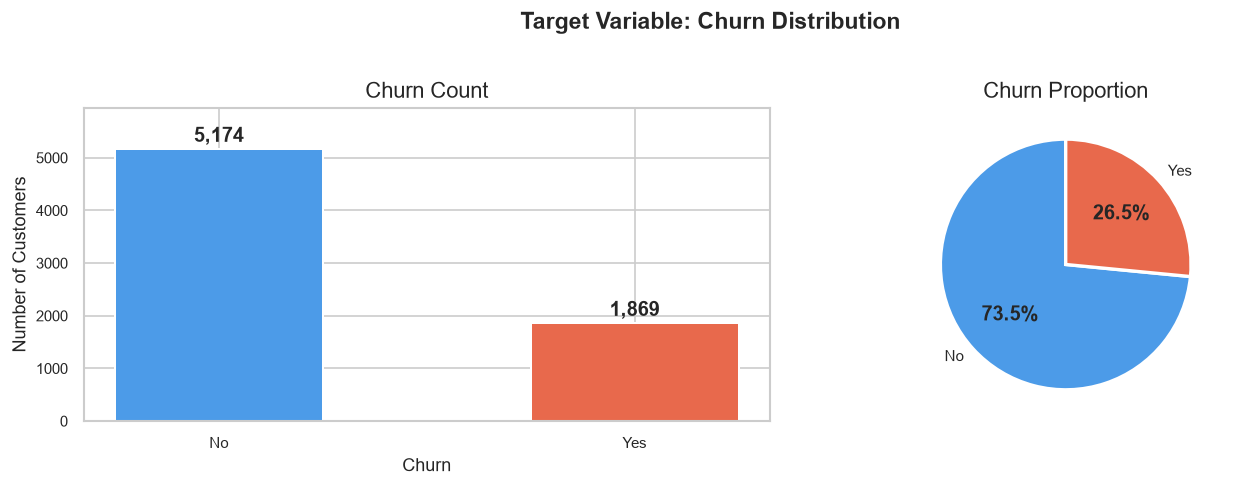

In [5]:
# --- Churn counts and percentages ---
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
for val in ['No', 'Yes']:
    print(f"  {val:4s}: {churn_counts[val]:5,}  ({churn_pct[val]:.2f}%)")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[CHURN_PALETTE[k] for k in churn_counts.index],
                   edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=[CHURN_PALETTE[k] for k in churn_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_churn_distribution.png'), bbox_inches='tight')
plt.show()

### Observations
- The dataset is **imbalanced**: ~73.5% No-Churn vs ~26.5% Churn.
- Approximately **1 in 4 customers** left the company.

### Business Interpretation
- A 26.5% churn rate is significantly high for a telecom company.
- Customer acquisition costs typically far exceed retention costs — reducing churn by even 5% could have major revenue impact.

### Business Recommendation
- **Immediate priority:** Launch a retention programme targeting at-risk customers.
- **Model note:** Class imbalance must be addressed during modelling (SMOTE, class weighting).

## 6. Univariate Analysis <a id='6'></a>

We examine the distribution of each feature independently.

### 6.1 Demographic Features

**Business Question:** Are certain demographic groups more likely to churn?

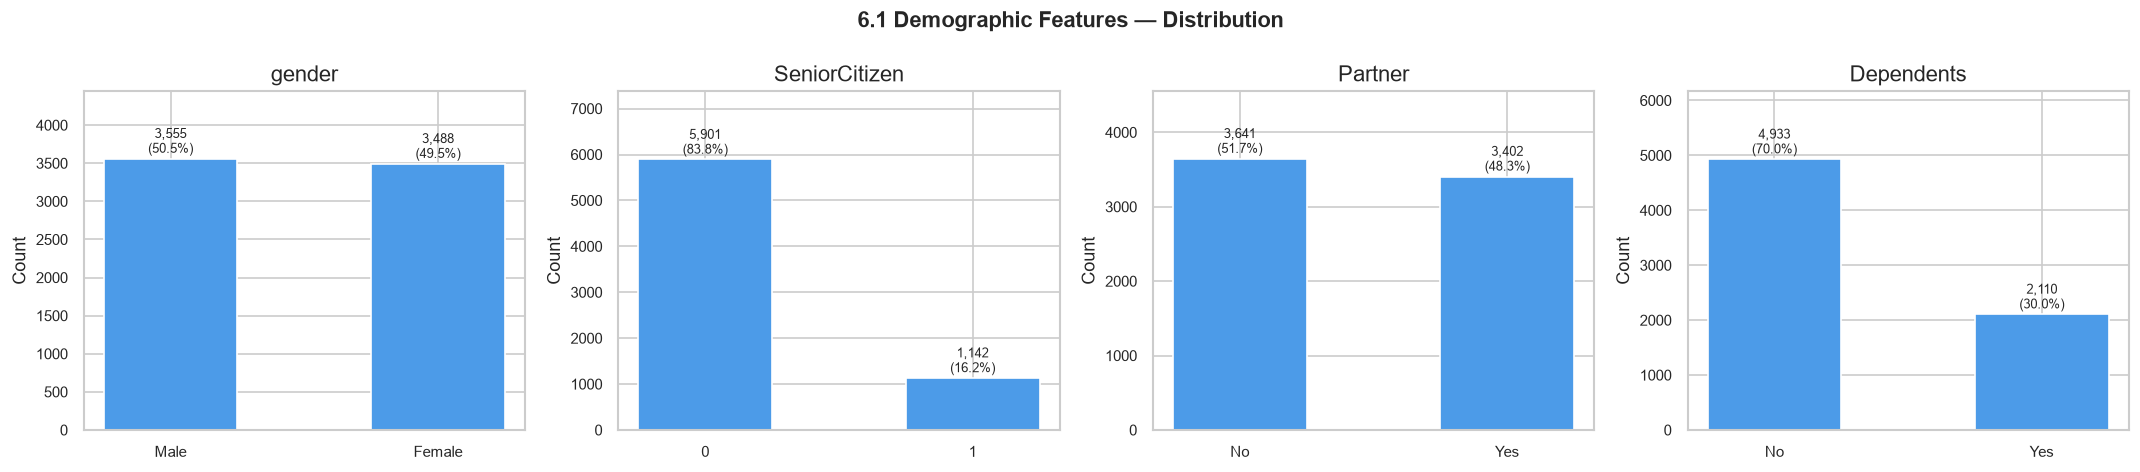

In [6]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(demo_cols):
    counts = df[col].value_counts()
    bars   = axes[i].bar(counts.index.astype(str), counts.values,
                         color=BAR_COLOR, edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].set_ylim(0, counts.max() * 1.25)

plt.suptitle('6.1 Demographic Features — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_demographics_univariate.png'), bbox_inches='tight')
plt.show()

| Feature | Observation | Business Interpretation | Recommendation |
|---|---|---|---|
| **Gender** | Near equal split (~50/50 Male/Female) | Gender alone is unlikely to be a strong churn driver | No gender-specific targeting needed |
| **SeniorCitizen** | ~84% Non-Senior, ~16% Senior | Seniors are a minority but may have different needs | Design senior-friendly plans and support |
| **Partner** | ~52% No Partner, ~48% With Partner | Slight majority are single; may have less commitment | Bundle family plans to increase stickiness |
| **Dependents** | ~70% No Dependents, ~30% With Dependents | Customers without dependents may have less reason to stay | Family/household bundles can improve retention |

### 6.2 Account Features

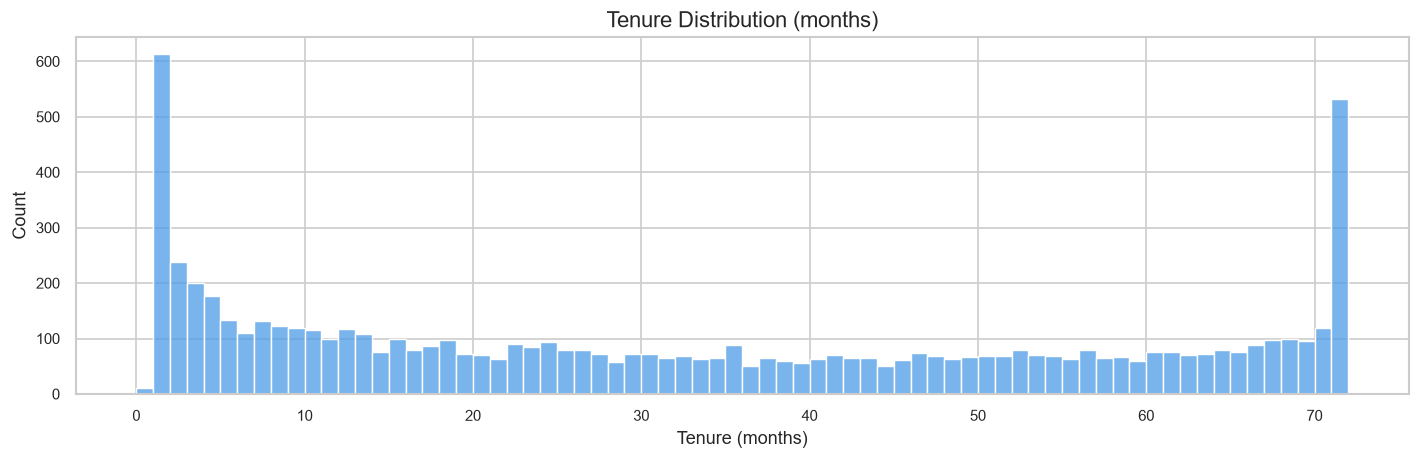

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000


In [7]:
# Tenure distribution
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(df['tenure'], bins=72, color=BAR_COLOR, edgecolor='white', ax=ax)
ax.set_title('Tenure Distribution (months)')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_tenure_distribution.png'), bbox_inches='tight')
plt.show()

print(df['tenure'].describe().to_string())

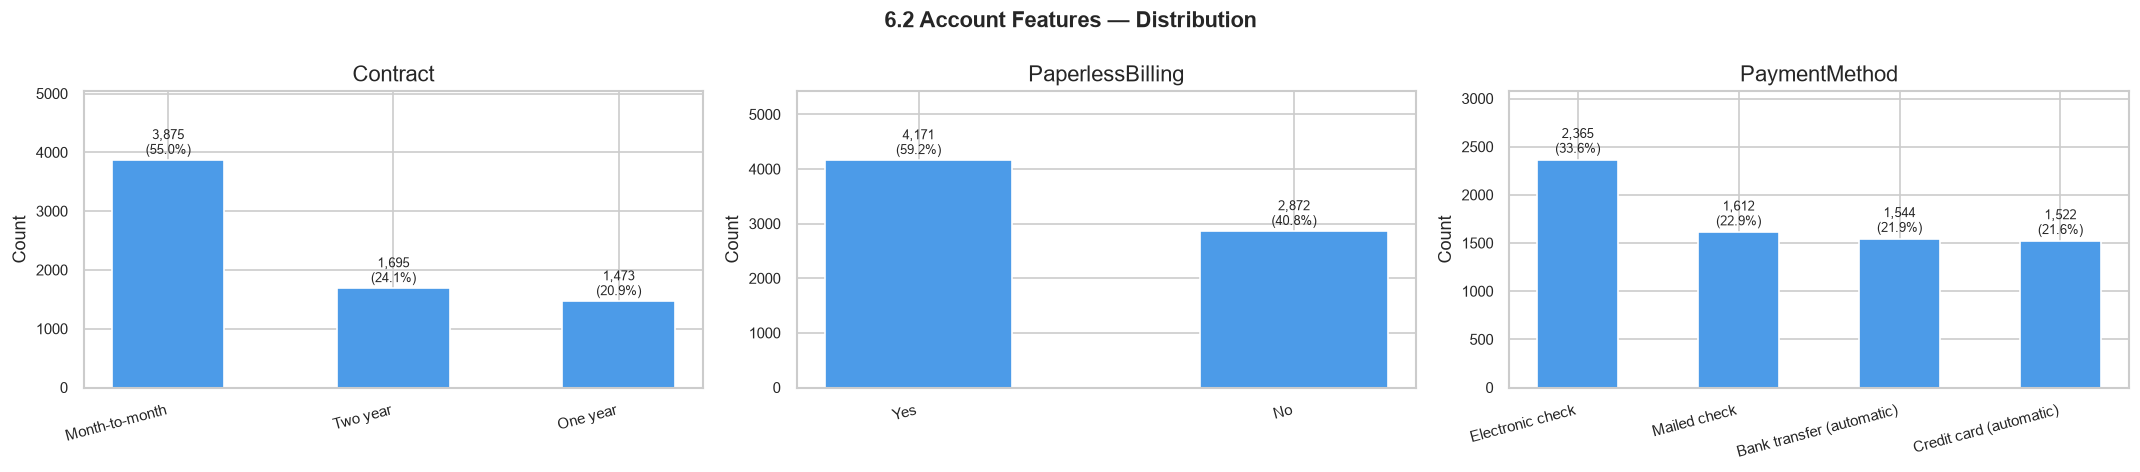

In [8]:
# Contract, PaperlessBilling, PaymentMethod
account_cat_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(account_cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(range(len(counts)), counts.values, color=BAR_COLOR,
                       edgecolor='white', width=0.5)
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=15, ha='right')
    for bar, v in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].set_ylim(0, counts.max() * 1.3)

plt.suptitle('6.2 Account Features — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_account_features_univariate.png'), bbox_inches='tight')
plt.show()

| Feature | Observation | Business Interpretation | Recommendation |
|---|---|---|---|
| **Tenure** | Bimodal — spikes at month 1 and month 72 | Many very new and very long-term customers; mid-tenure customers in between | Focus retention at months 1–12 (highest exit risk) |
| **Contract** | ~55% Month-to-Month, ~21% One Year, ~24% Two Year | Majority are on flexible plans with no lock-in | Incentivise customers to upgrade to 1 or 2-year contracts |
| **PaperlessBilling** | ~59% Paperless, ~41% Paper | Most opted for digital billing | Monitor if paperless users have higher churn (digital-native but less loyal) |
| **PaymentMethod** | Electronic Check most common (~34%), then Credit Card, Bank Transfer, Mailed Check | High Electronic Check usage may indicate less committed customers | Promote auto-pay options (Bank Transfer/Credit Card) to reduce churn risk |

### 6.3 Service Features

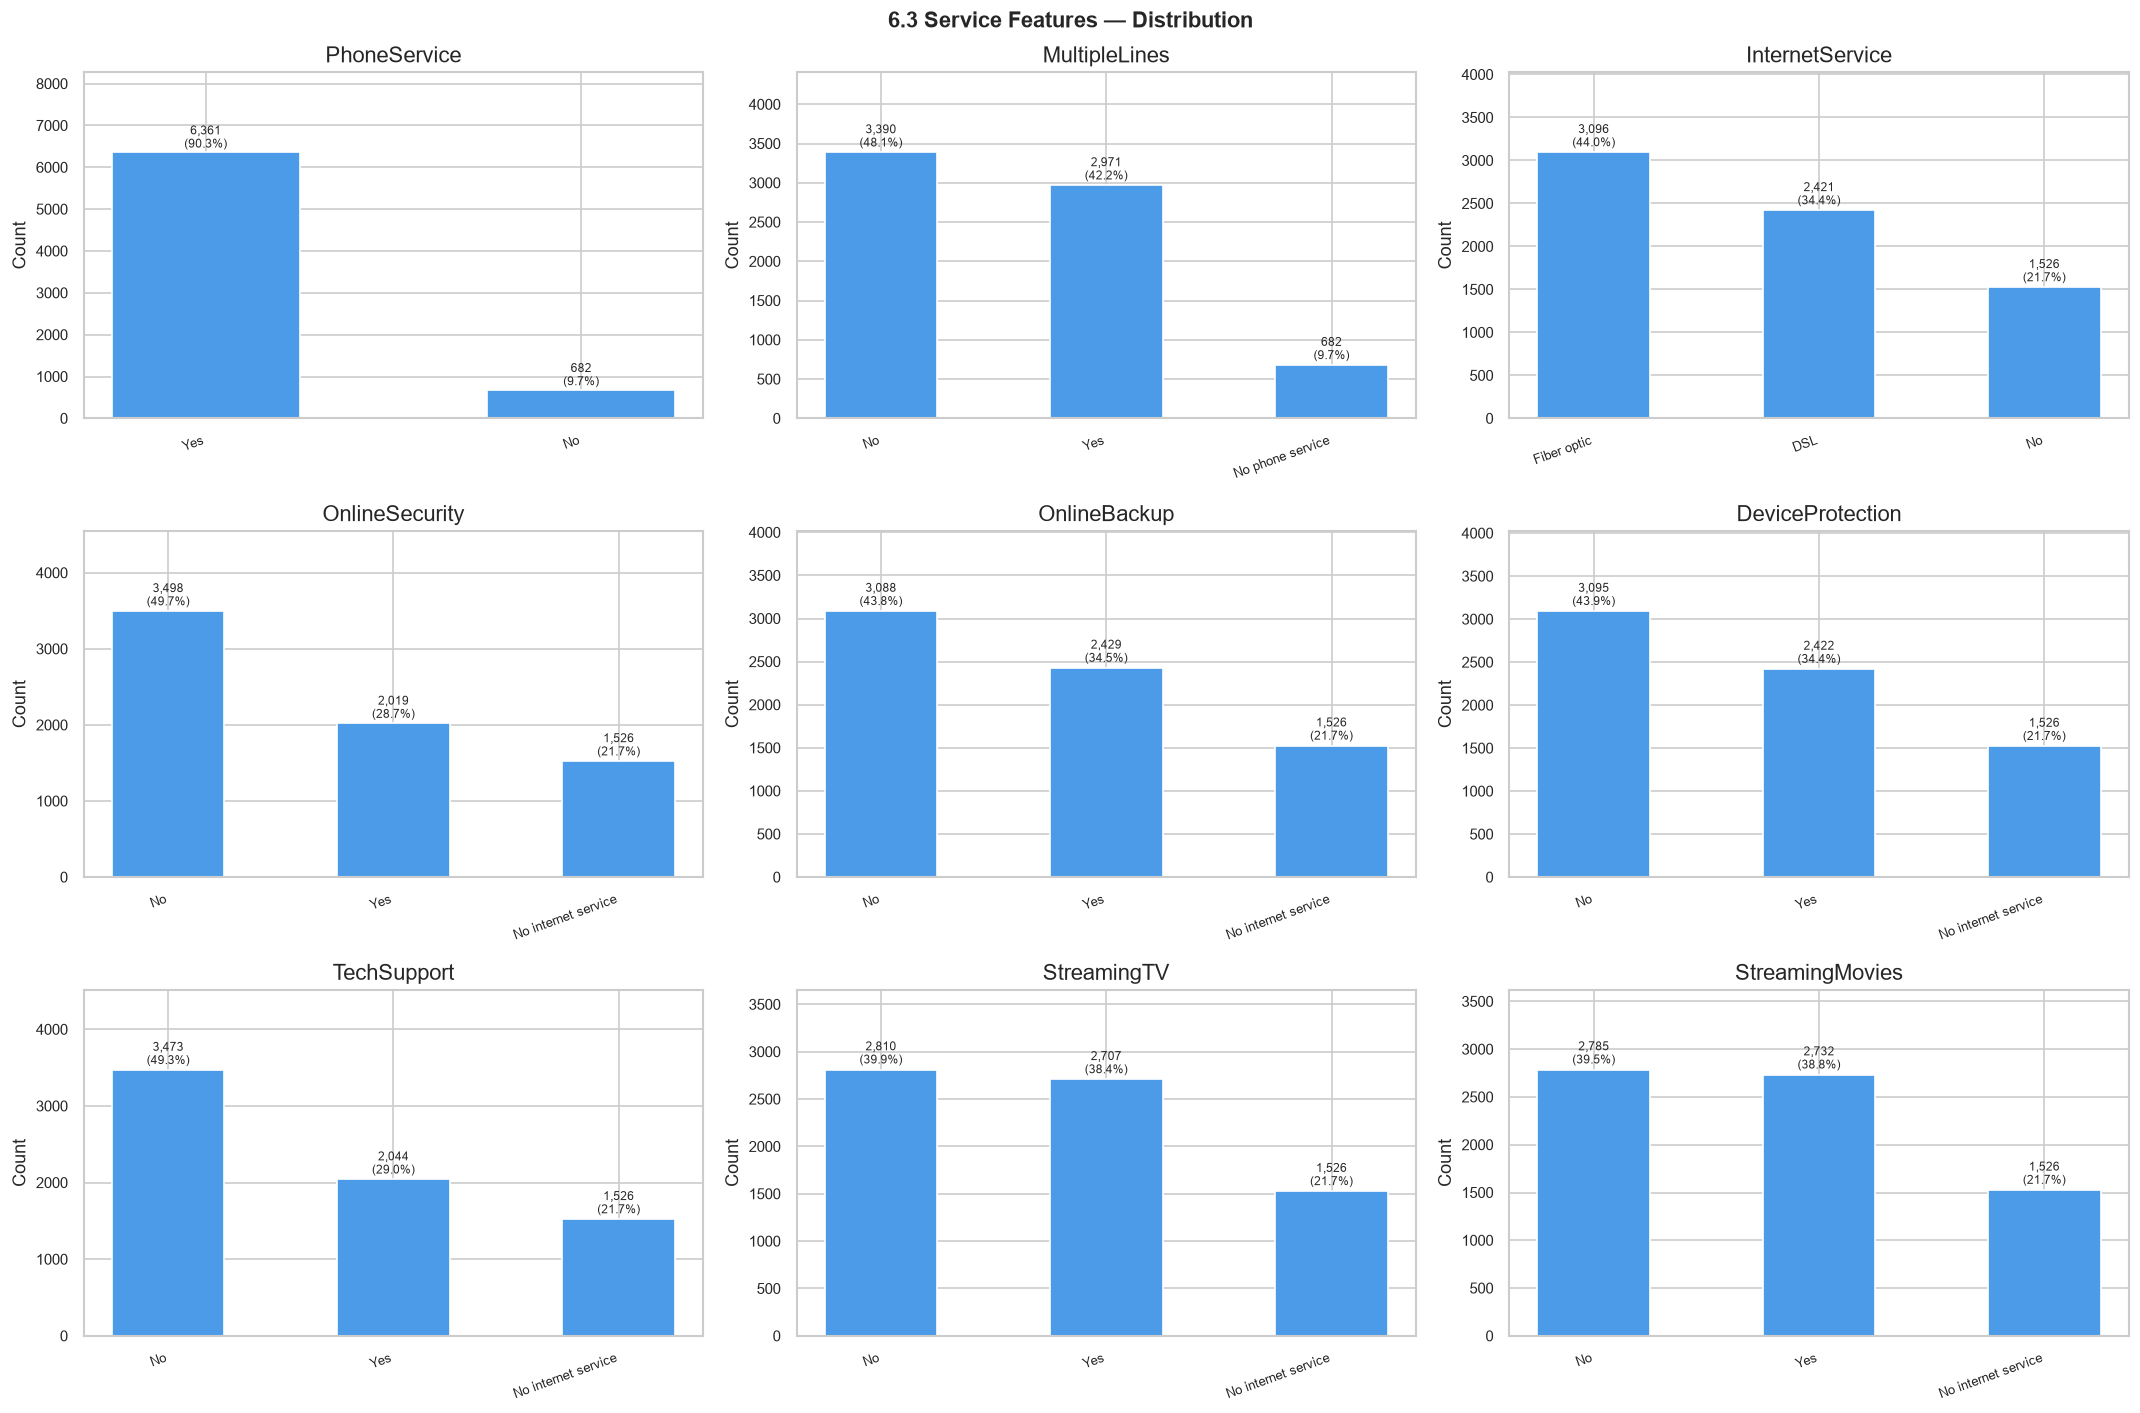

In [9]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(range(len(counts)), counts.values, color=BAR_COLOR,
                       edgecolor='white', width=0.5)
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=20, ha='right', fontsize=8)
    for bar, v in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                     f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].set_ylim(0, counts.max() * 1.3)

plt.suptitle('6.3 Service Features — Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_service_features_univariate.png'), bbox_inches='tight')
plt.show()

| Feature | Observation | Business Interpretation | Recommendation |
|---|---|---|---|
| **PhoneService** | ~90% have phone service | Almost universal adoption | Not a strong differentiator for churn |
| **MultipleLines** | ~42% No, ~42% Yes, ~16% No phone service | Even split among phone users | MultipleLines may indicate higher value customers |
| **InternetService** | ~44% Fiber Optic, ~34% DSL, ~22% No | Fiber is the most popular; premium segment | Investigate Fiber customer experience — may be expensive |
| **OnlineSecurity** | ~50% No, ~29% Yes, ~21% No internet | Many customers lack security add-ons | Promote security bundles; may reduce churn |
| **OnlineBackup** | ~44% No, ~34% Yes, ~22% No internet | Similar to security — low adoption | Bundle backup with security as a value package |
| **DeviceProtection** | ~44% No, ~34% Yes, ~22% No internet | Low adoption of device protection | Market device protection to reduce vulnerability |
| **TechSupport** | ~50% No, ~29% Yes, ~21% No internet | Many do not use tech support | Customers without support may leave if they face issues |
| **StreamingTV** | ~40% No, ~38% Yes, ~22% No internet | Near equal split | Streaming services add value; could improve retention |
| **StreamingMovies** | ~40% No, ~39% Yes, ~21% No internet | Near equal split | Similar to StreamingTV |

### 6.4 Financial Features

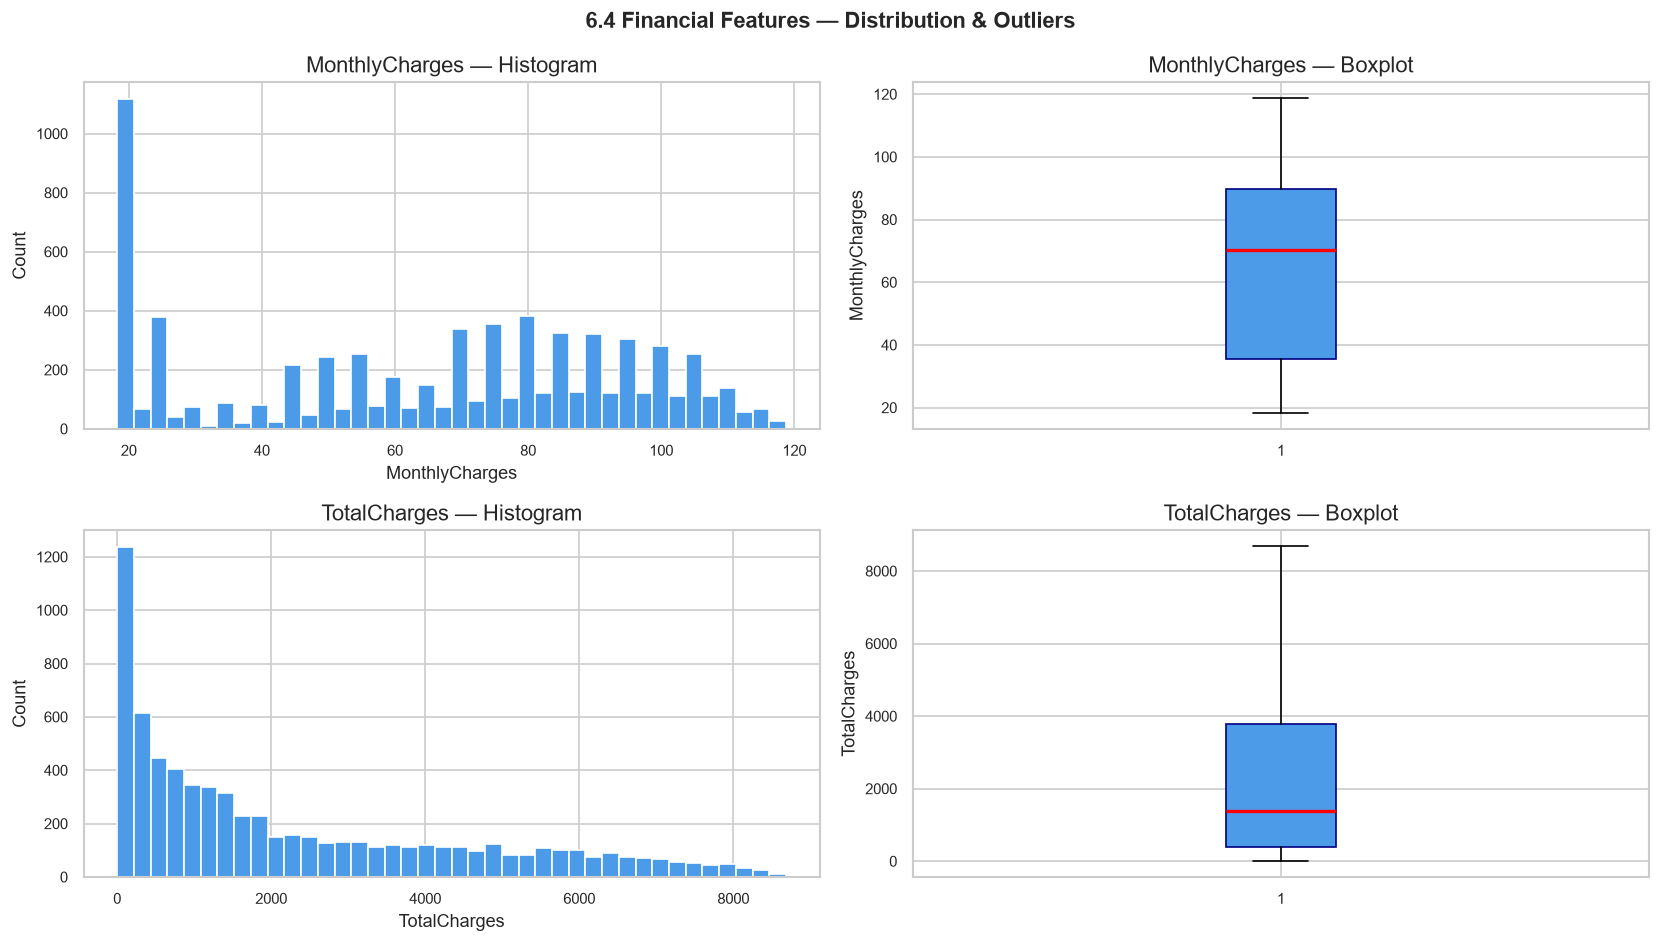

Summary Statistics:
                 count         mean          std    min     25%      50%      75%      max
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35    89.85   118.75
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55  3786.60  8684.80


In [10]:
fin_cols = ['MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(fin_cols):
    # Histogram
    axes[i][0].hist(df[col], bins=40, color=BAR_COLOR, edgecolor='white')
    axes[i][0].set_title(f'{col} — Histogram')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')

    # Boxplot
    axes[i][1].boxplot(df[col], patch_artist=True, vert=True,
                       boxprops=dict(facecolor=BAR_COLOR, color='navy'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i][1].set_title(f'{col} — Boxplot')
    axes[i][1].set_ylabel(col)

plt.suptitle('6.4 Financial Features — Distribution & Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_financial_features_univariate.png'), bbox_inches='tight')
plt.show()

# Stats
print("Summary Statistics:")
print(df[fin_cols].describe().T.to_string())

| Feature | Observation | Outlier Assessment | Business Interpretation |
|---|---|---|---|
| **MonthlyCharges** | Range: $18–$118; Mean ~$64; roughly uniform | Few high-end outliers ($100+) | Premium customers pay more — could be at risk if value is not justified |
| **TotalCharges** | Right-skewed; 0 to $8,684; Mean ~$2,279 | High values for long-tenure customers (valid) | Strongly correlated with tenure; long-term customers have high CLV |

## 7. Bivariate Analysis — Feature vs Churn <a id='7'></a>

Helper function used throughout this section:

In [11]:
# Helper: compute churn rate per category
def churn_rate_by(col):
    return (
        df.groupby(col)['Churn']
          .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
          .reset_index()
          .rename(columns={'Churn': 'Churn Rate (%)'})
          .sort_values('Churn Rate (%)', ascending=False)
    )

# Helper: plot count + churn rate side-by-side
def plot_bivariate(col, ax1, ax2, title=None):
    # Count plot
    sns.countplot(data=df, x=col, hue='Churn',
                  palette=CHURN_PALETTE, ax=ax1, order=df[col].value_counts().index)
    ax1.set_title(title or col)
    ax1.set_xlabel('')
    ax1.tick_params(axis='x', rotation=15)
    ax1.legend(title='Churn')

    # Churn rate bar
    cr = churn_rate_by(col)
    bars = ax2.bar(cr[col].astype(str), cr['Churn Rate (%)'], color='#E8694C',
                   edgecolor='white', width=0.5)
    for bar, v in zip(bars, cr['Churn Rate (%)']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_title(f'{col} — Churn Rate')
    ax2.set_xlabel('')
    ax2.set_ylabel('Churn Rate (%)')
    ax2.tick_params(axis='x', rotation=15)
    ax2.set_ylim(0, cr['Churn Rate (%)'].max() * 1.25)

print("Helper functions defined.")

Helper functions defined.


### 7.1 Demographic Features vs Churn

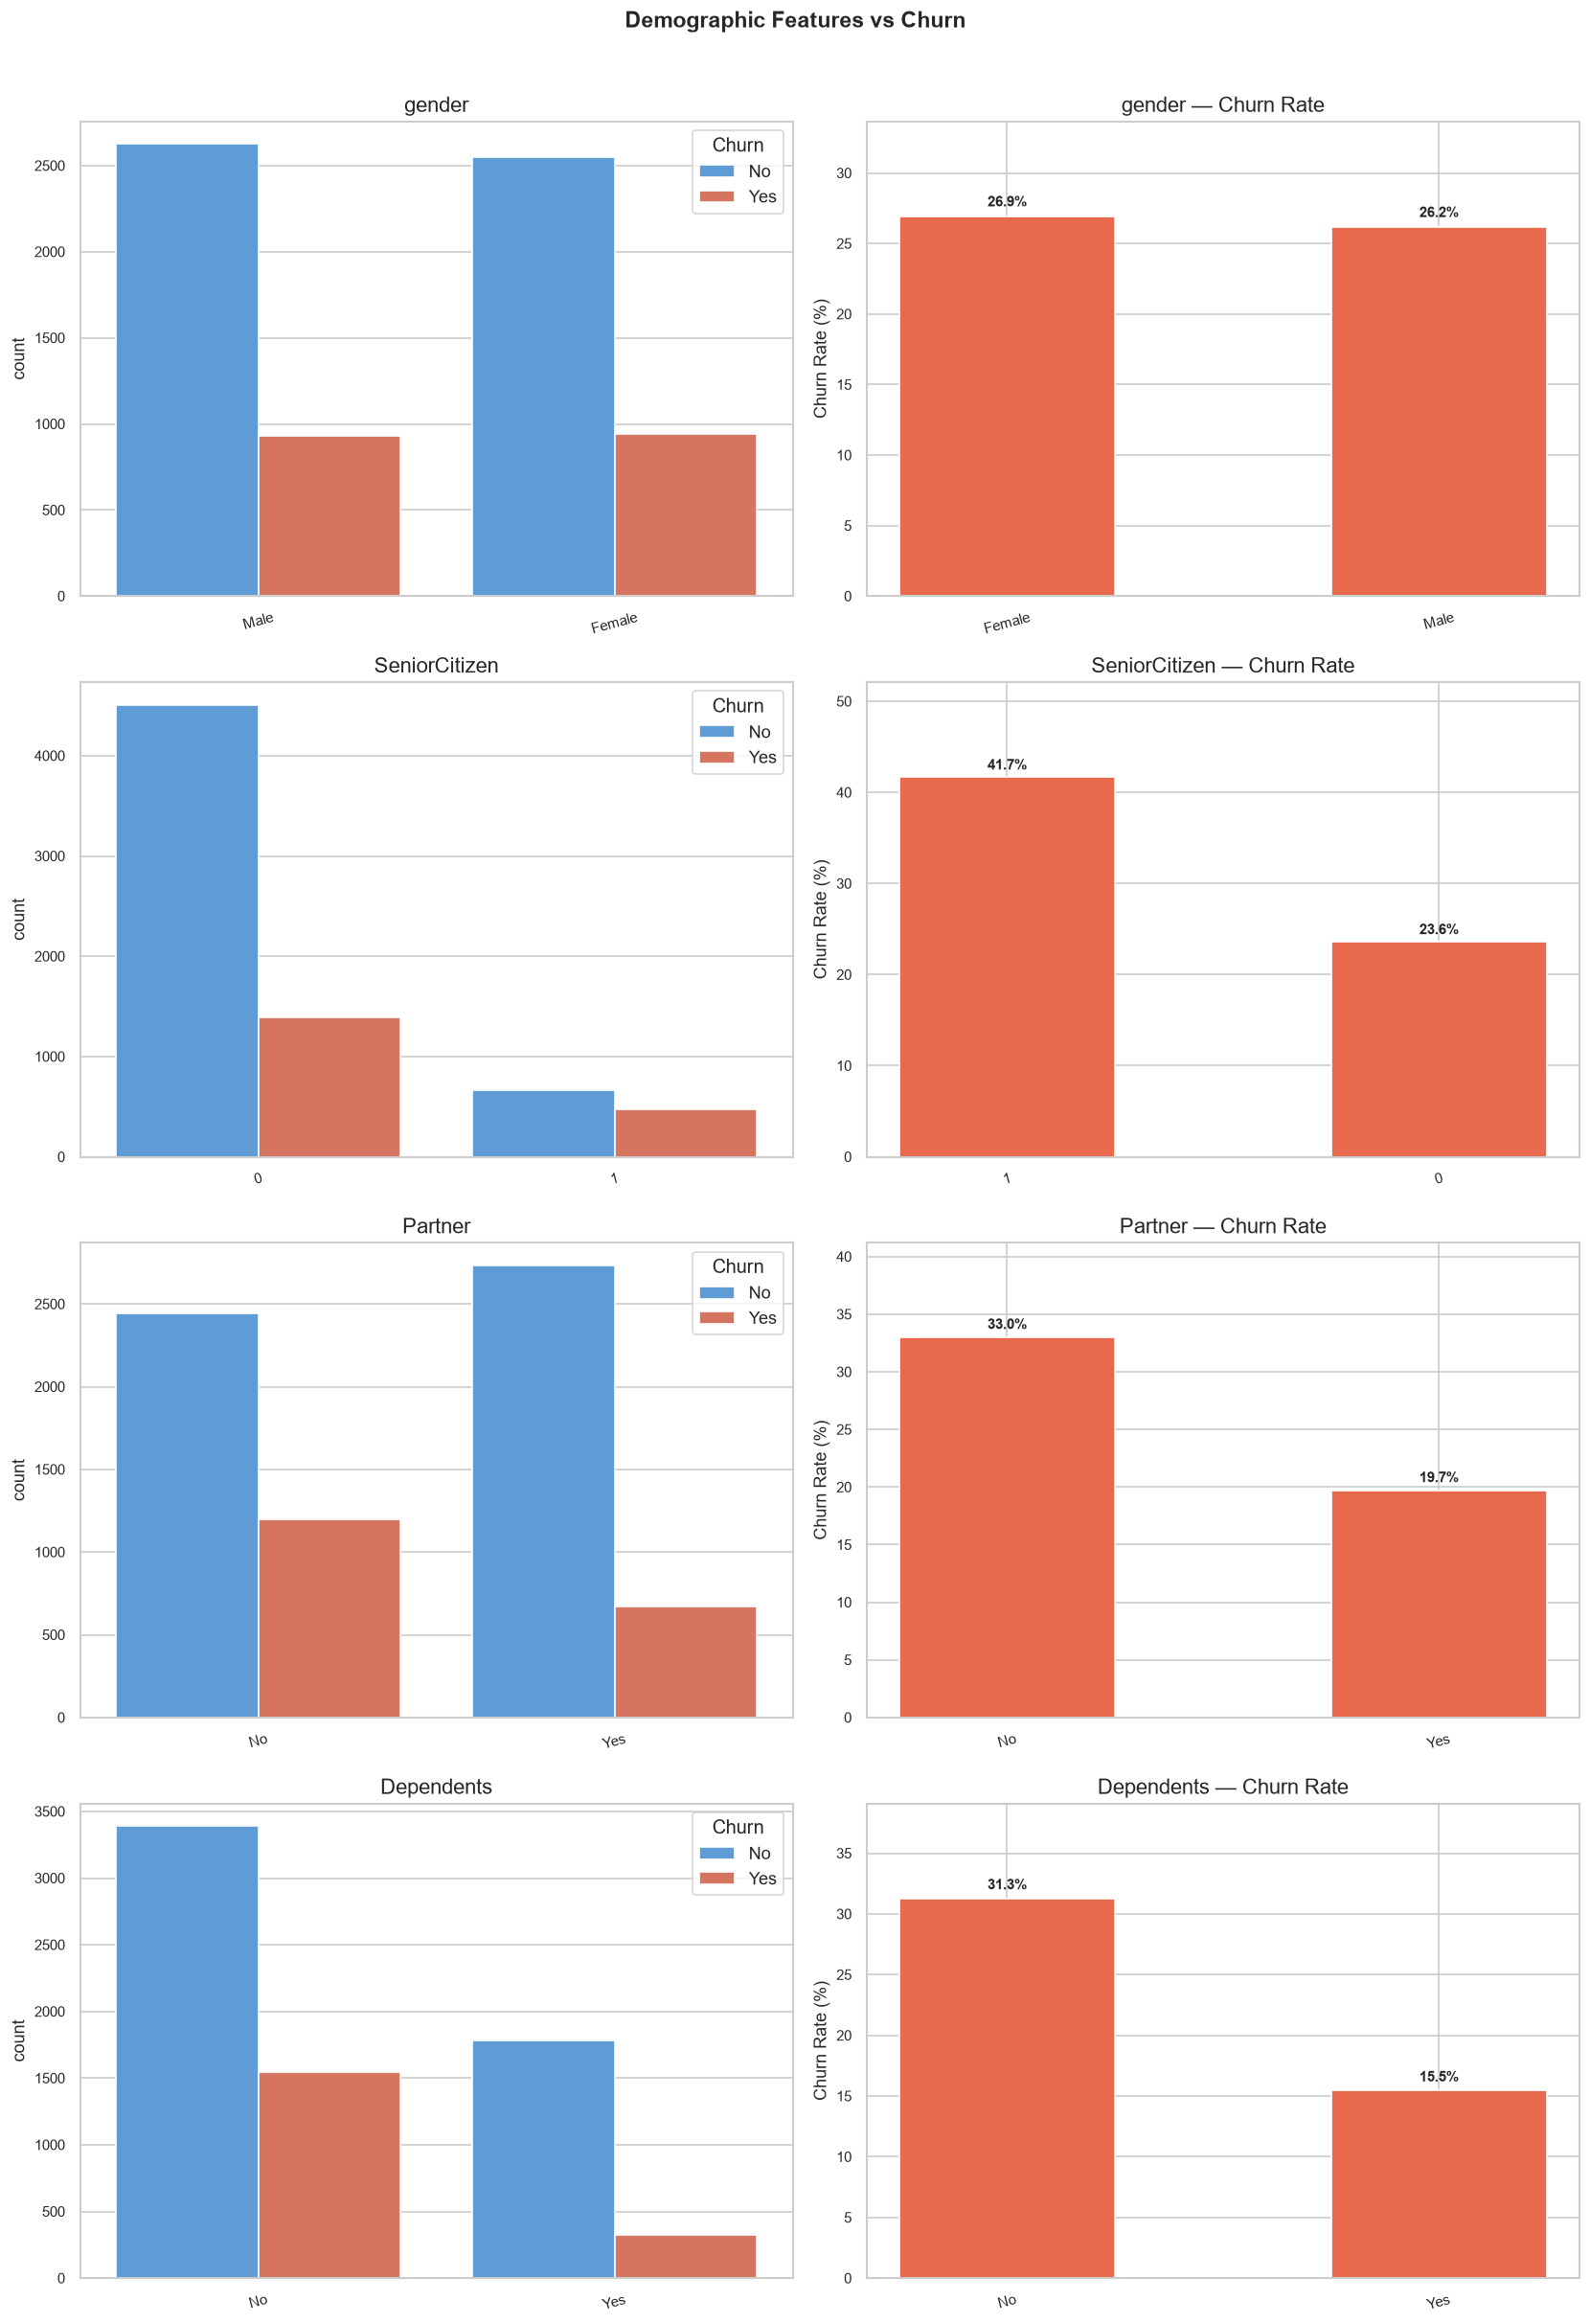

Churn Rates:

gender:
gender  Churn Rate (%)
Female       26.920872
  Male       26.160338

SeniorCitizen:
 SeniorCitizen  Churn Rate (%)
             1       41.681261
             0       23.606168

Partner:
Partner  Churn Rate (%)
     No       32.957979
    Yes       19.664903

Dependents:
Dependents  Churn Rate (%)
        No       31.279140
       Yes       15.450237


In [12]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, col in enumerate(demo_cols):
    plot_bivariate(col, axes[i][0], axes[i][1])

plt.suptitle('Demographic Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_demographics_vs_churn.png'), bbox_inches='tight')
plt.show()

# Print churn rates
print("Churn Rates:")
for col in demo_cols:
    print(f"\n{col}:")
    print(churn_rate_by(col).to_string(index=False))

| Feature | Churn Rate | Observation | Business Interpretation | Recommendation |
|---|---|---|---|---|
| **Gender** | Male ~26%, Female ~27% | No meaningful difference | Gender is not a churn predictor | No gender-specific action required |
| **SeniorCitizen** | Senior ~42%, Non-Senior ~24% | Seniors churn significantly more | Seniors may struggle with technology or find plans too expensive | Offer senior-specific discounts and dedicated support |
| **Partner** | No Partner ~33%, With Partner ~20% | Customers without partners churn more | Single customers have less household commitment | Bundle offers for couples/families |
| **Dependents** | No Dependents ~31%, With Dependents ~16% | Customers with dependents are far more loyal | Family accounts have higher switching costs | Promote family plan benefits to retain at-risk singles |

### 7.2 Account Features vs Churn

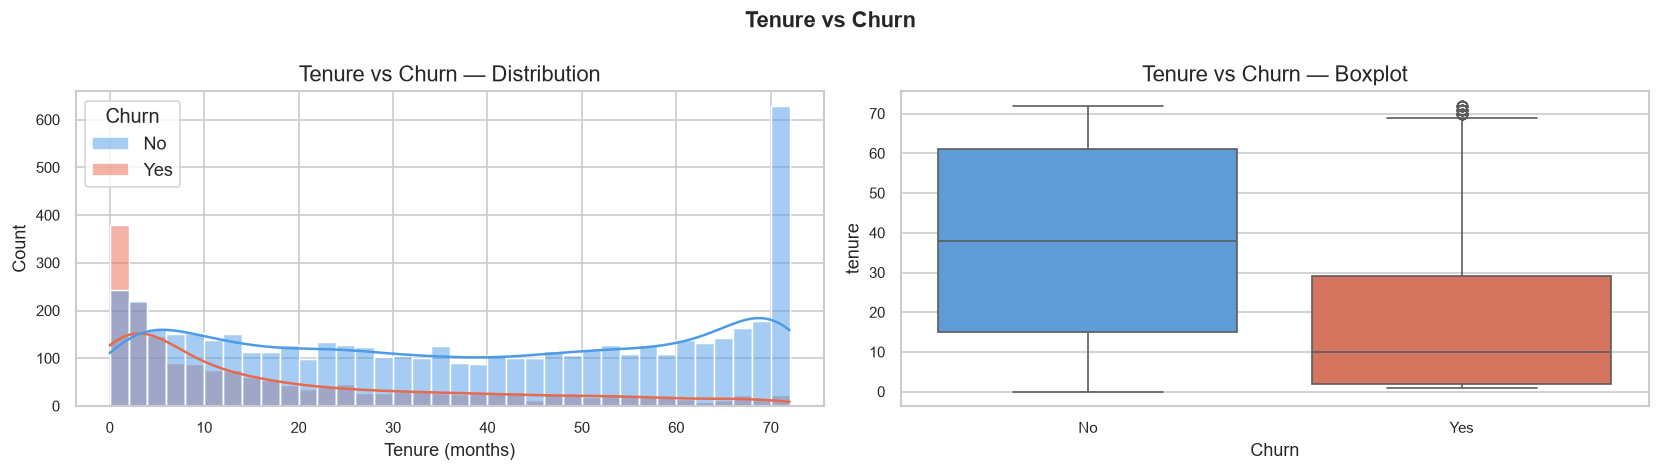

Median Tenure by Churn:
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [13]:
# Tenure vs Churn — KDE plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True,
             palette=CHURN_PALETTE, ax=axes[0], bins=36)
axes[0].set_title('Tenure vs Churn — Distribution')
axes[0].set_xlabel('Tenure (months)')

# Boxplot: tenure by churn
sns.boxplot(data=df, x='Churn', y='tenure', palette=CHURN_PALETTE, ax=axes[1])
axes[1].set_title('Tenure vs Churn — Boxplot')

plt.suptitle('Tenure vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_tenure_vs_churn.png'), bbox_inches='tight')
plt.show()

print("Median Tenure by Churn:")
print(df.groupby('Churn')['tenure'].median())

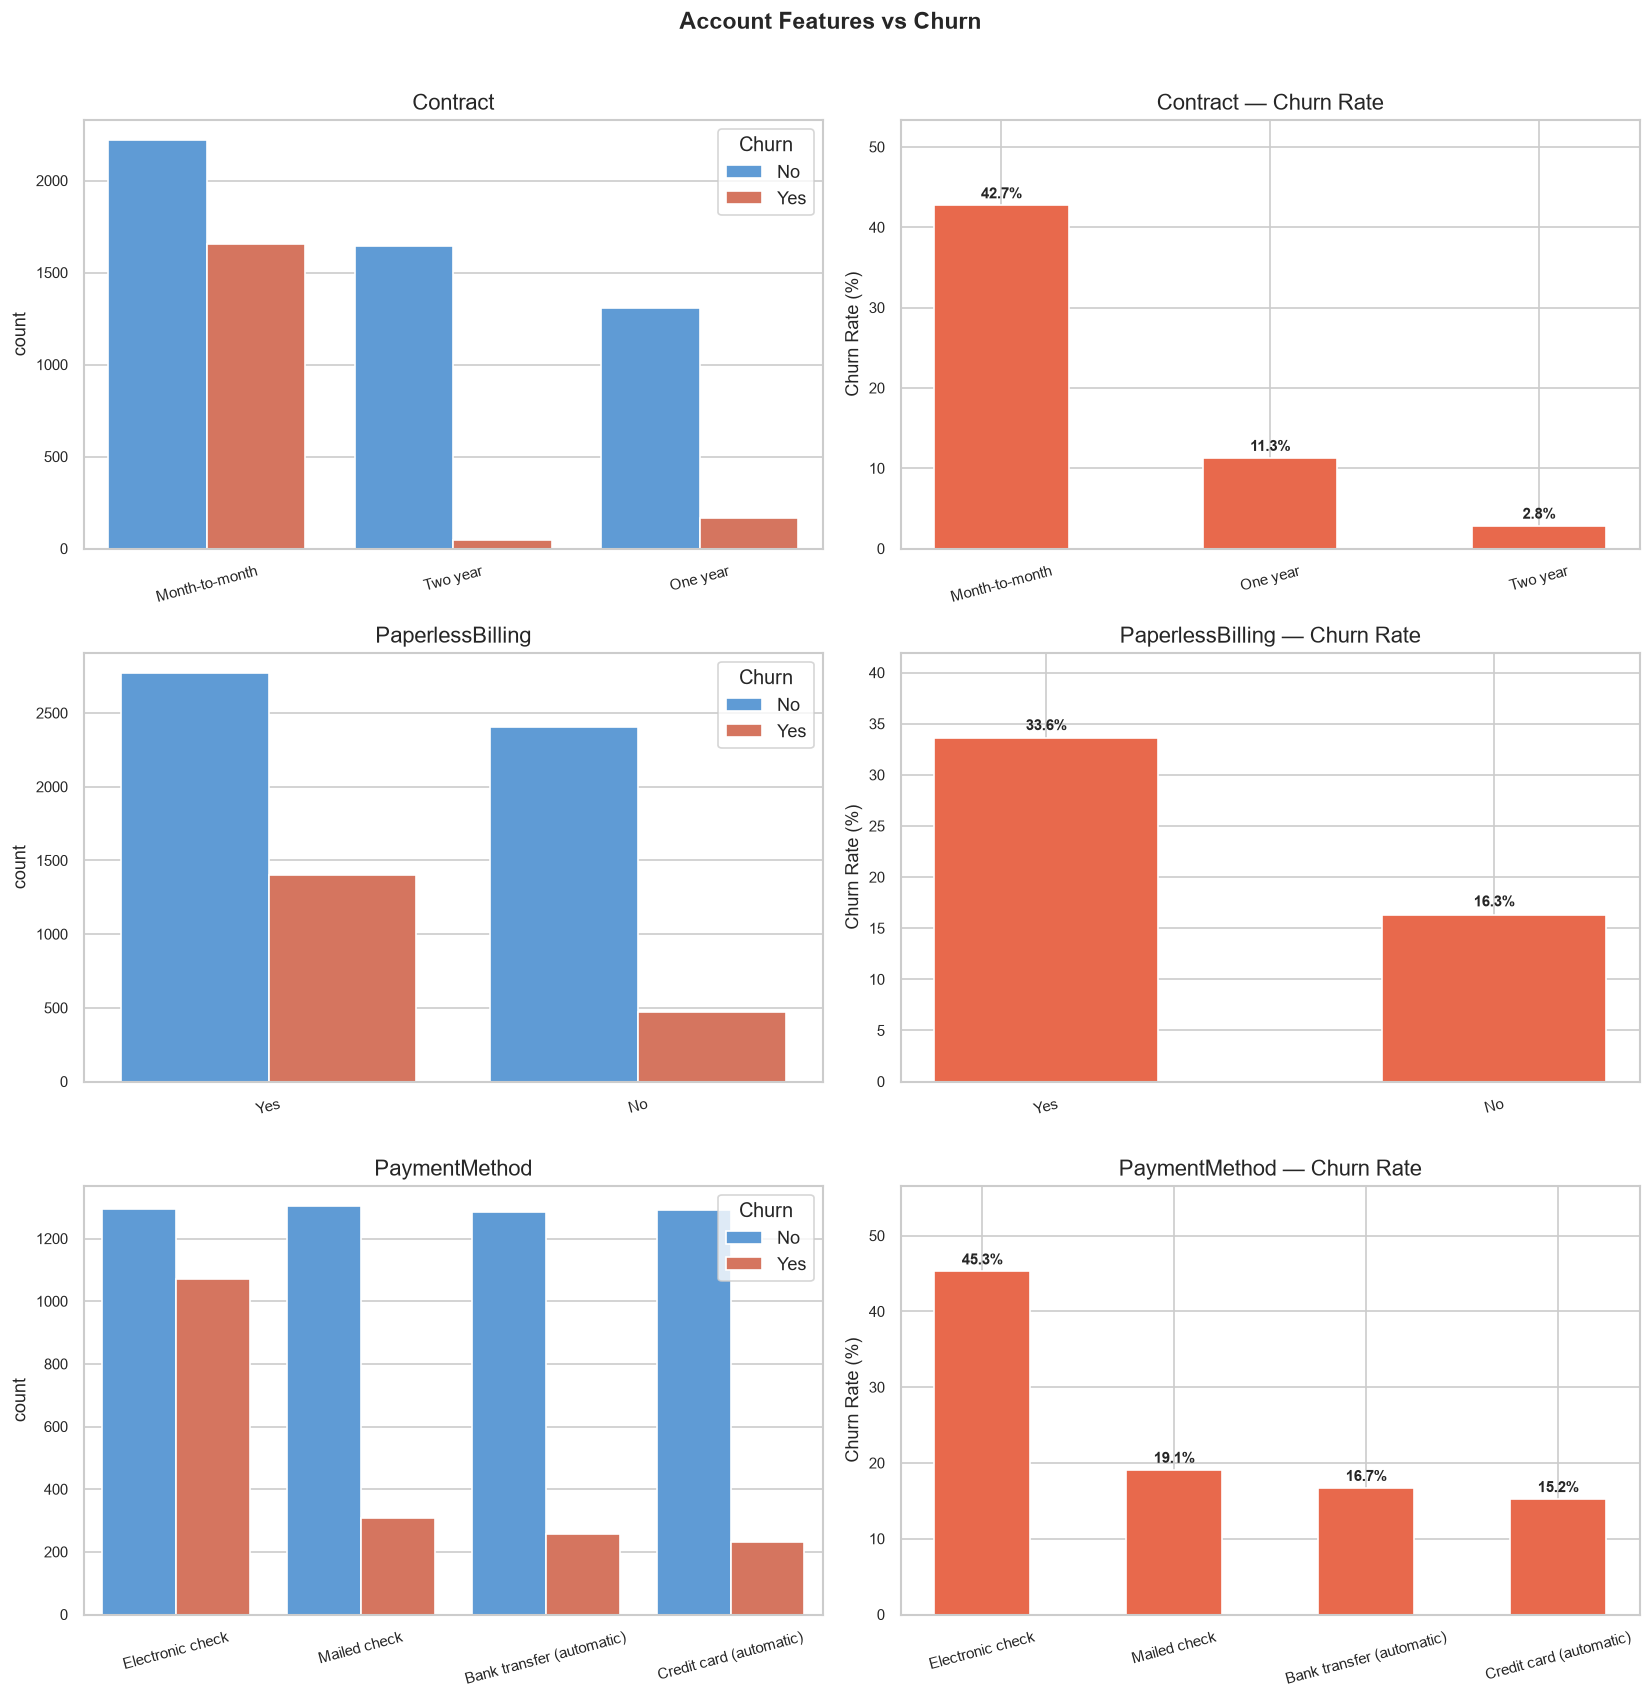

Churn Rates:

Contract:
      Contract  Churn Rate (%)
Month-to-month       42.709677
      One year       11.269518
      Two year        2.831858

PaperlessBilling:
PaperlessBilling  Churn Rate (%)
             Yes       33.565092
              No       16.330084

PaymentMethod:
            PaymentMethod  Churn Rate (%)
         Electronic check       45.285412
             Mailed check       19.106700
Bank transfer (automatic)       16.709845
  Credit card (automatic)       15.243101


In [14]:
# Contract, PaperlessBilling, PaymentMethod vs Churn
account_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for i, col in enumerate(account_cols):
    plot_bivariate(col, axes[i][0], axes[i][1])

plt.suptitle('Account Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_account_vs_churn.png'), bbox_inches='tight')
plt.show()

print("Churn Rates:")
for col in account_cols:
    print(f"\n{col}:")
    print(churn_rate_by(col).to_string(index=False))

| Feature | Key Churn Rates | Observation | Business Interpretation | Recommendation |
|---|---|---|---|---|
| **Tenure** | Churners: median ~10 months; Loyal: ~38 months | New customers churn far more | First year is the critical retention window | Invest in onboarding and early-stage customer success |
| **Contract** | Month-to-Month: ~43%; One Year: ~11%; Two Year: ~3% | **Strongest account churn driver** | Flexible plans give customers an easy exit | Offer discounts and perks to upgrade to longer contracts |
| **PaperlessBilling** | Paperless: ~34%; Paper: ~17% | Paperless users churn almost 2x more | May be correlated with digital/younger customers who compare plans more | Investigate if paperless billing creates disengagement |
| **PaymentMethod** | Electronic Check: ~45%; Others ~15–20% | Electronic Check users churn dramatically more | May reflect less committed or financially stressed customers | Incentivise auto-pay (Credit Card, Bank Transfer) |

### 7.3 Service Features vs Churn

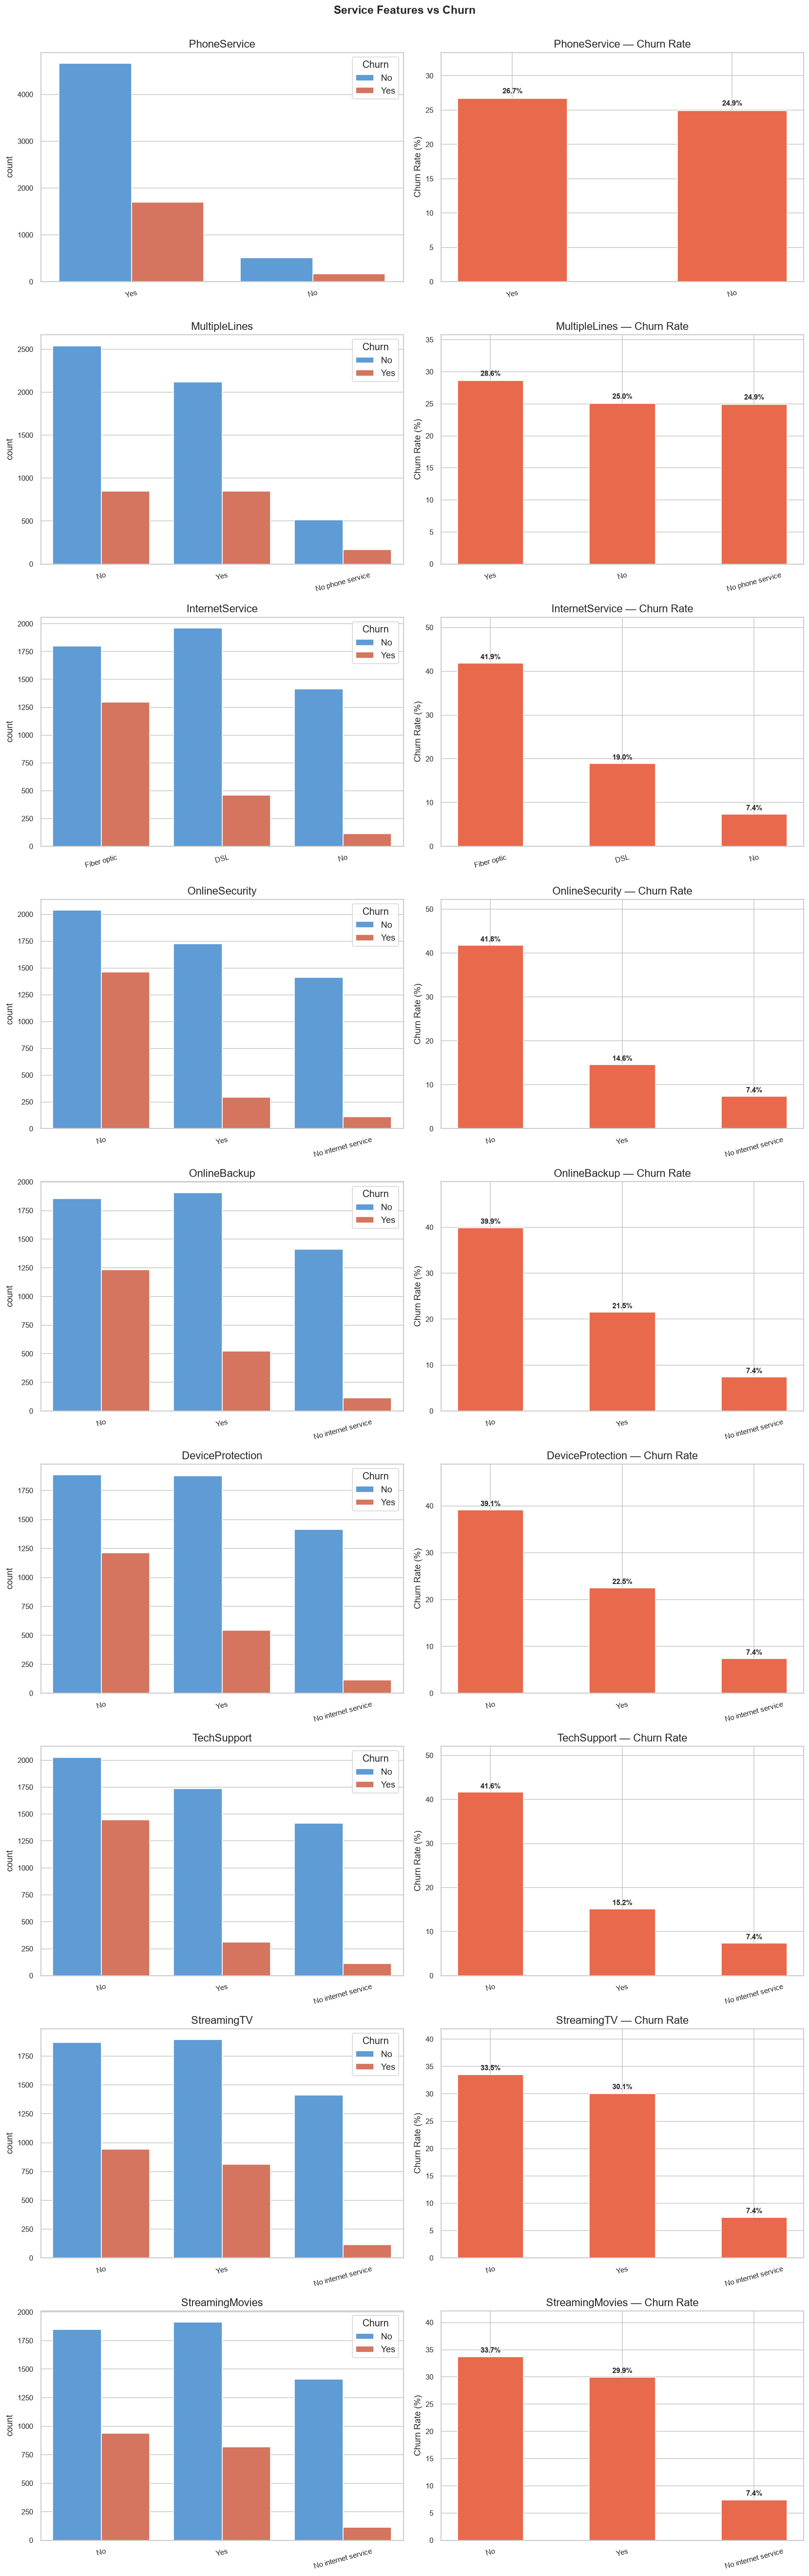

Churn Rates:

PhoneService:
PhoneService  Churn Rate (%)
         Yes       26.709637
          No       24.926686

MultipleLines:
   MultipleLines  Churn Rate (%)
             Yes       28.609896
              No       25.044248
No phone service       24.926686

InternetService:
InternetService  Churn Rate (%)
    Fiber optic       41.892765
            DSL       18.959108
             No        7.404980

OnlineSecurity:
     OnlineSecurity  Churn Rate (%)
                 No       41.766724
                Yes       14.611194
No internet service        7.404980

OnlineBackup:
       OnlineBackup  Churn Rate (%)
                 No       39.928756
                Yes       21.531494
No internet service        7.404980

DeviceProtection:
   DeviceProtection  Churn Rate (%)
                 No       39.127625
                Yes       22.502064
No internet service        7.404980

TechSupport:
        TechSupport  Churn Rate (%)
                 No       41.635474
                Yes   

In [15]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(9, 2, figsize=(14, 44))
for i, col in enumerate(service_cols):
    plot_bivariate(col, axes[i][0], axes[i][1])

plt.suptitle('Service Features vs Churn', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_service_vs_churn.png'), bbox_inches='tight')
plt.show()

print("Churn Rates:")
for col in service_cols:
    print(f"\n{col}:")
    print(churn_rate_by(col).to_string(index=False))

| Feature | Key Churn Rates | Observation | Business Interpretation | Recommendation |
|---|---|---|---|---|
| **PhoneService** | Yes: ~27%, No: ~25% | No meaningful difference | Phone service alone does not protect from churn | Not a key lever |
| **MultipleLines** | No: ~25%, Yes: ~29%, No phone: ~25% | Slight increase with multiple lines | Multiple lines = higher bill = potential price sensitivity | Monitor usage and offer value-add to multi-line users |
| **InternetService** | Fiber Optic: ~42%, DSL: ~19%, No: ~7% | **Fiber users churn ~2x DSL** | Fiber may be expensive; competitors may offer better deals | Investigate Fiber customer satisfaction and pricing |
| **OnlineSecurity** | No: ~42%, Yes: ~15%, No internet: ~7% | Customers without security churn significantly more | Security add-ons increase perceived value and reduce switching | Promote online security bundles proactively |
| **OnlineBackup** | No: ~40%, Yes: ~22%, No internet: ~7% | Backup service reduces churn materially | Value-added services create switching costs | Bundle backup with security as a discounted package |
| **DeviceProtection** | No: ~39%, Yes: ~23%, No internet: ~7% | Device protection reduces churn | Similar to backup — creates loyalty through added value | Offer device protection at sign-up |
| **TechSupport** | No: ~42%, Yes: ~15%, No internet: ~7% | **Strongest service-level churn reducer** | Supported customers are far more loyal | Make tech support accessible and promote it |
| **StreamingTV** | No: ~34%, Yes: ~30%, No internet: ~7% | Modest reduction in churn | Streaming adds entertainment value | Bundle streaming with security/support |
| **StreamingMovies** | No: ~34%, Yes: ~30%, No internet: ~7% | Similar to StreamingTV | Modest loyalty driver | Bundle streaming services for retention |

### 7.4 Financial Features vs Churn

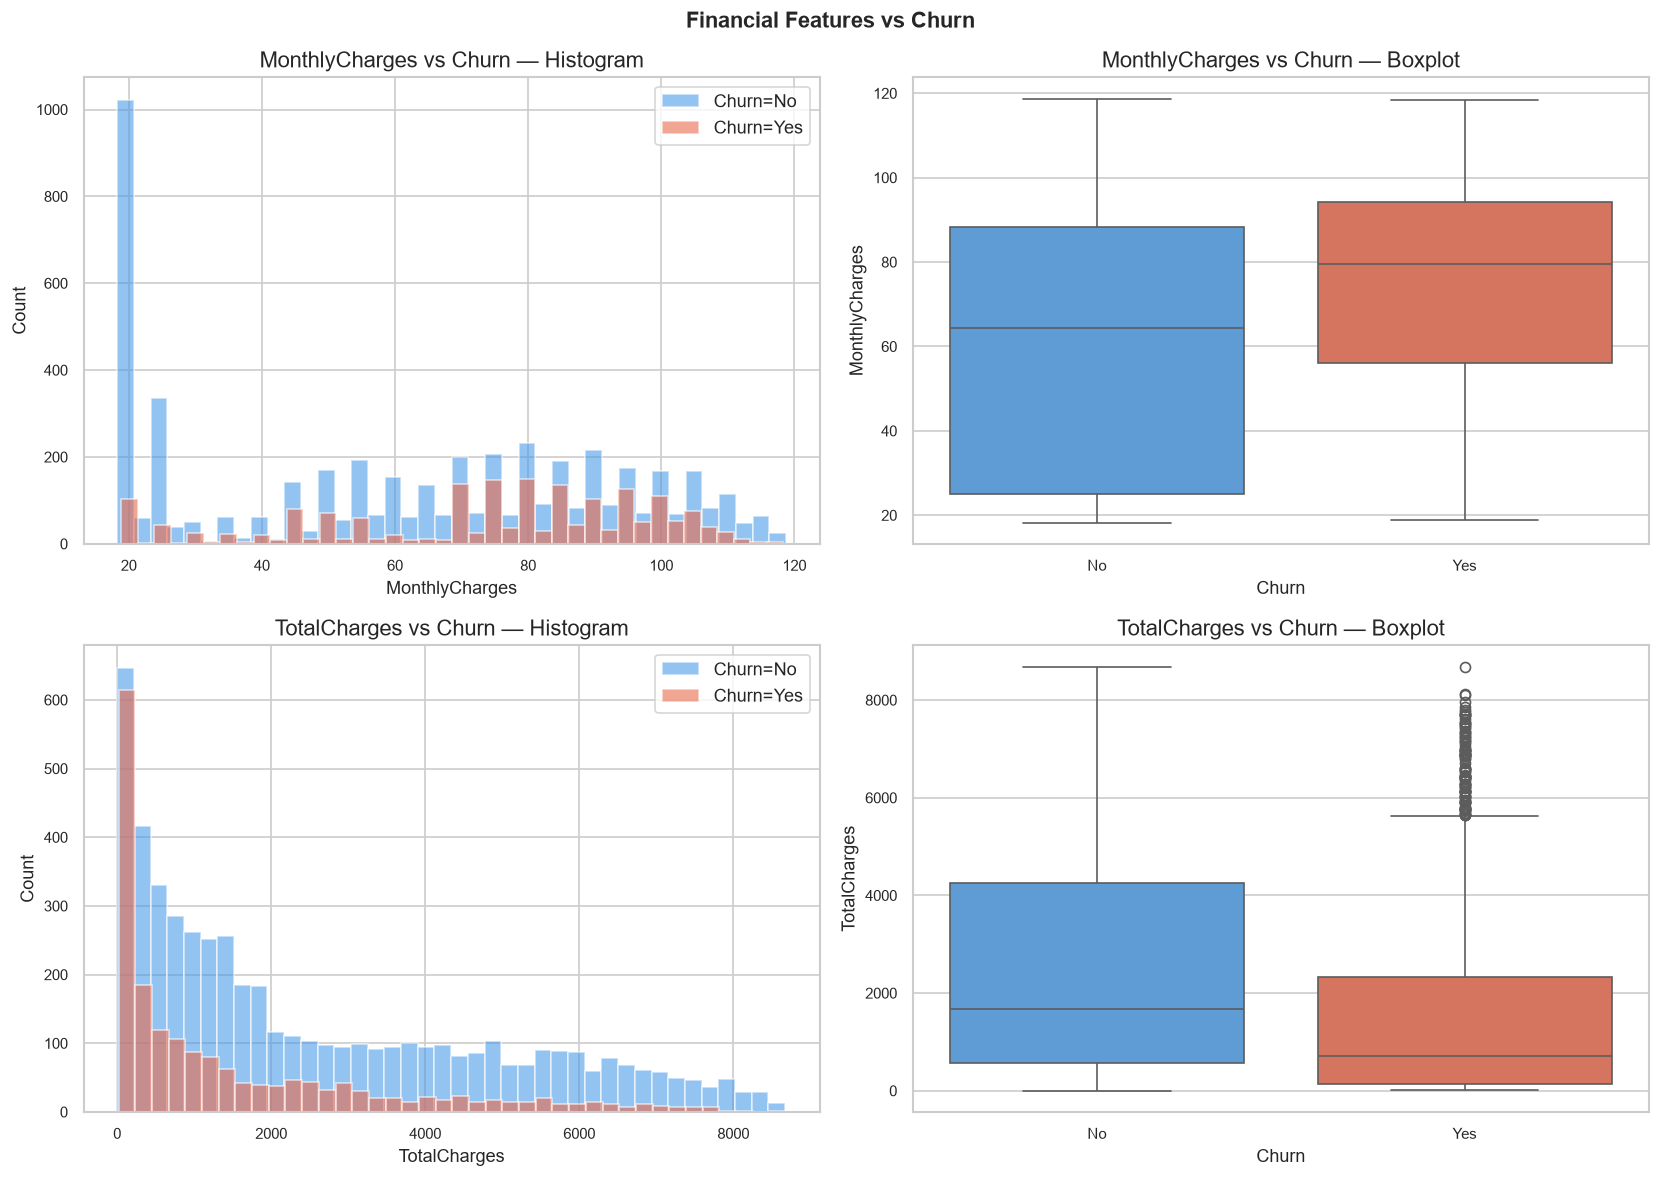

Mean Financial Values by Churn:
       MonthlyCharges  TotalCharges
Churn                              
No              61.27       2549.91
Yes             74.44       1531.80


In [16]:
fin_cols = ['MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(fin_cols):
    # Histogram by Churn
    for churn_val, color in CHURN_PALETTE.items():
        subset = df[df['Churn'] == churn_val][col]
        axes[i][0].hist(subset, bins=40, alpha=0.6, label=f'Churn={churn_val}', color=color, edgecolor='white')
    axes[i][0].set_title(f'{col} vs Churn — Histogram')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')
    axes[i][0].legend()

    # Boxplot by Churn
    sns.boxplot(data=df, x='Churn', y=col, palette=CHURN_PALETTE, ax=axes[i][1])
    axes[i][1].set_title(f'{col} vs Churn — Boxplot')

plt.suptitle('Financial Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '11_financial_vs_churn.png'), bbox_inches='tight')
plt.show()

print("Mean Financial Values by Churn:")
print(df.groupby('Churn')[fin_cols].mean().round(2))

| Feature | Churners (Mean) | Non-Churners (Mean) | Observation | Business Interpretation | Recommendation |
|---|---|---|---|---|---|
| **MonthlyCharges** | ~$74 | ~$61 | Churners pay **~$13/month more** | Higher charges increase price sensitivity and churn risk | Review pricing tiers; offer loyalty discounts for high-paying customers |
| **TotalCharges** | ~$1,531 | ~$2,556 | Non-churners have higher total charges (longer tenure) | TotalCharges is a proxy for tenure — not independently predictive | Use tenure as the primary loyalty metric |

## 8. Multivariate Analysis <a id='8'></a>

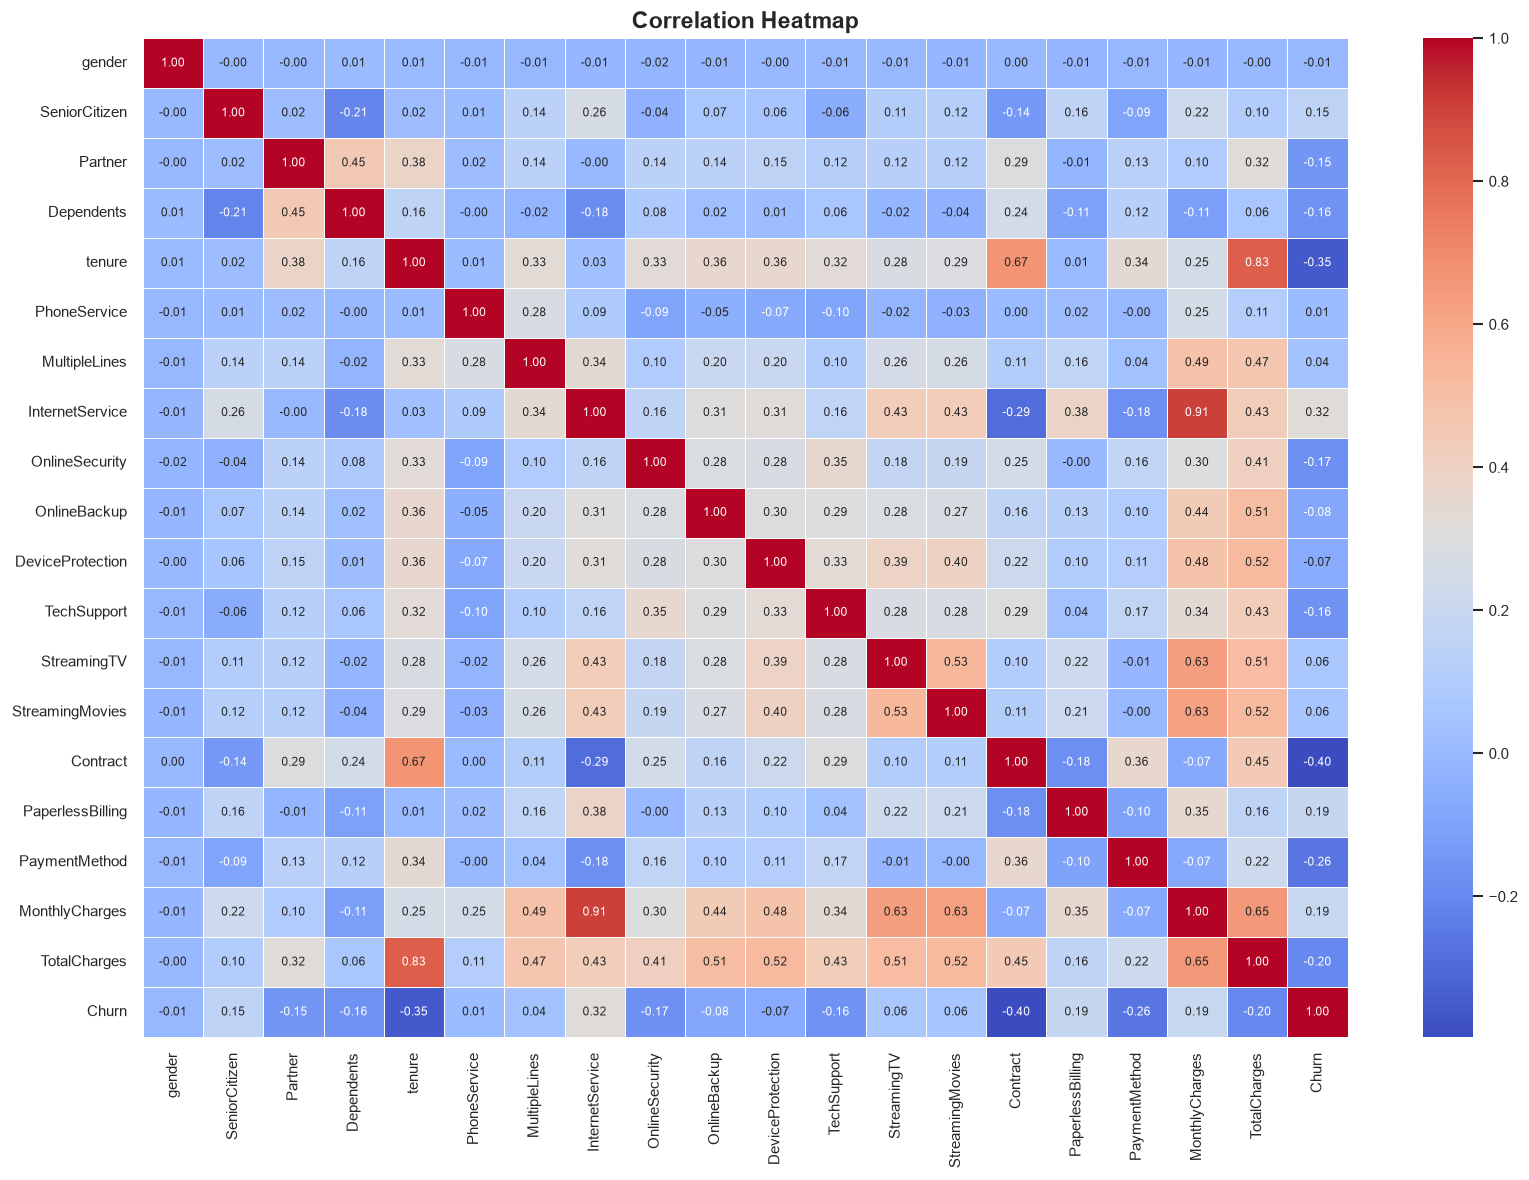

In [17]:
# --- 8.1 Correlation Heatmap ---
df_enc = df.copy()

# Encode binary columns
binary_map = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df_enc[col] = df_enc[col].map(binary_map)

# Encode SeniorCitizen is already int
# Encode other categoricals
df_enc['gender']         = df_enc['gender'].map({'Male': 1, 'Female': 0})
df_enc['Contract']       = df_enc['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_enc['InternetService']= df_enc['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df_enc['PaymentMethod']  = df_enc['PaymentMethod'].map({
    'Electronic check': 0, 'Mailed check': 1,
    'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3
})

# For service cols, map Yes/No/No internet service
service_recode = {'No': 0, 'Yes': 1, 'No internet service': 0, 'No phone service': 0}
for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df_enc[col] = df_enc[col].map(service_recode)

num_df = df_enc.select_dtypes(include='number').drop(columns=['customerID'], errors='ignore')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '12_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

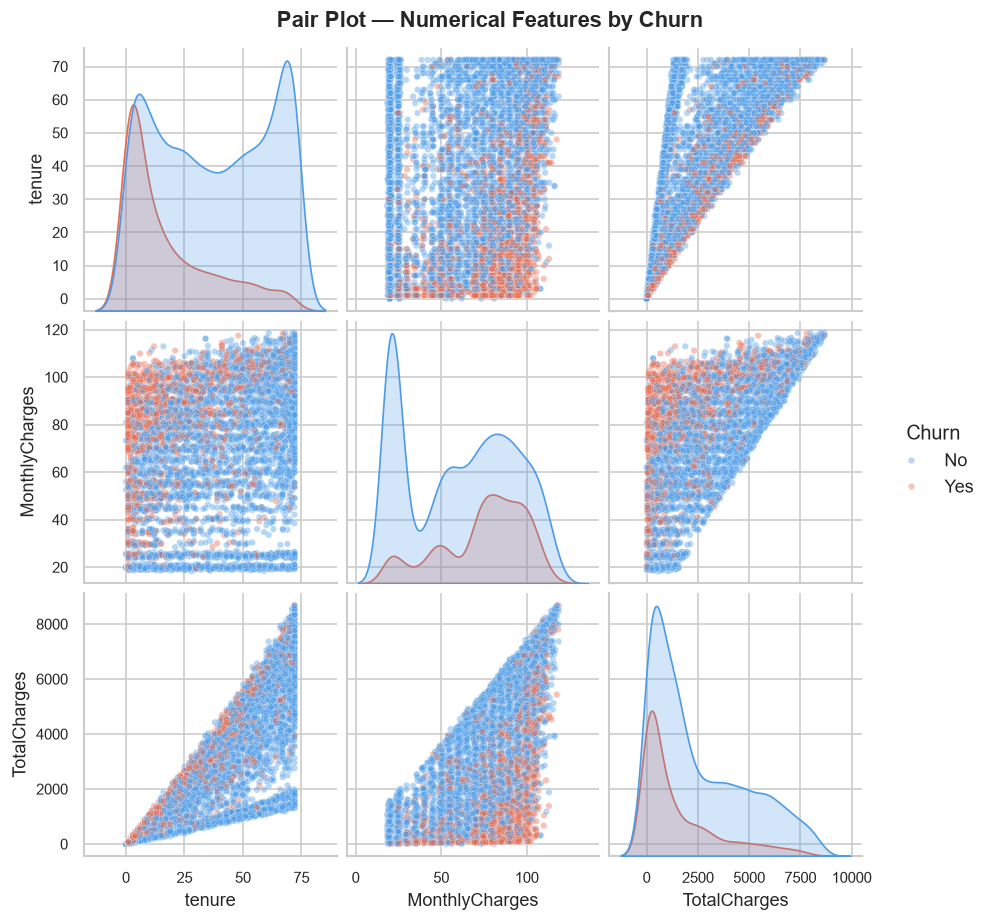

In [18]:
# --- 8.2 Pair Plot — Numerical Features ---
pair_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

g = sns.pairplot(pair_df, hue='Churn', palette=CHURN_PALETTE,
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pair Plot — Numerical Features by Churn', y=1.02, fontsize=13, fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, '13_pairplot.png'), bbox_inches='tight')
plt.show()

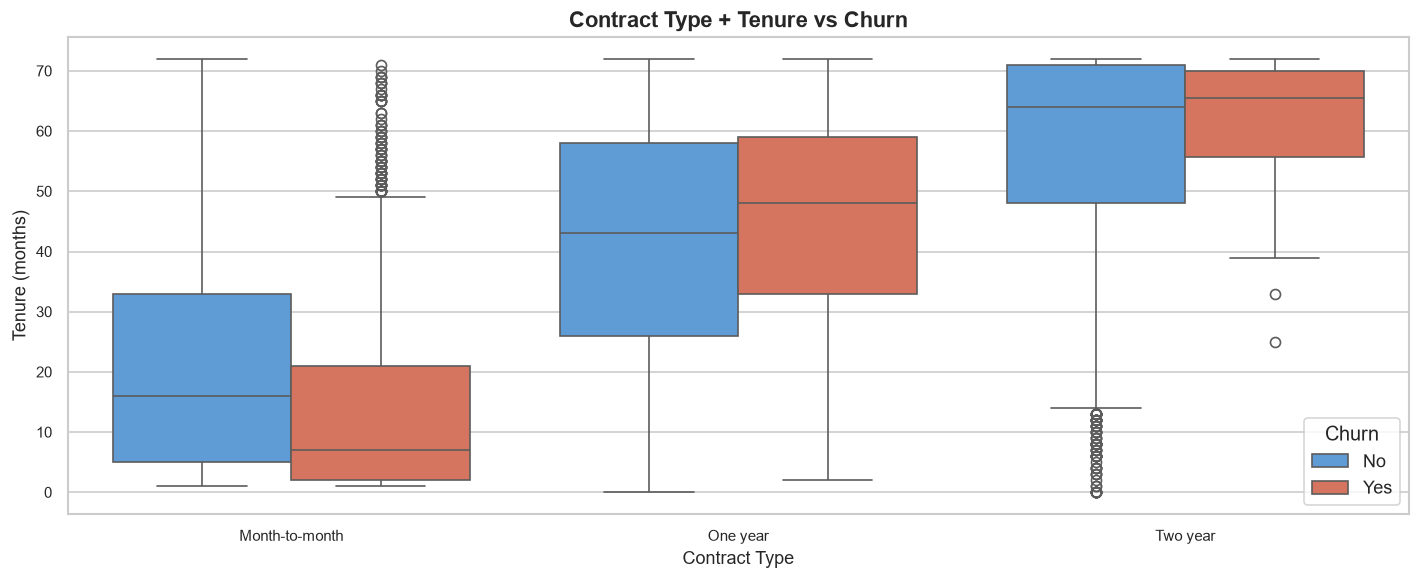

In [19]:
# --- 8.3 Contract + Tenure + Churn ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn',
            palette=CHURN_PALETTE, ax=ax)
ax.set_title('Contract Type + Tenure vs Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Tenure (months)')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '14_contract_tenure_churn.png'), bbox_inches='tight')
plt.show()

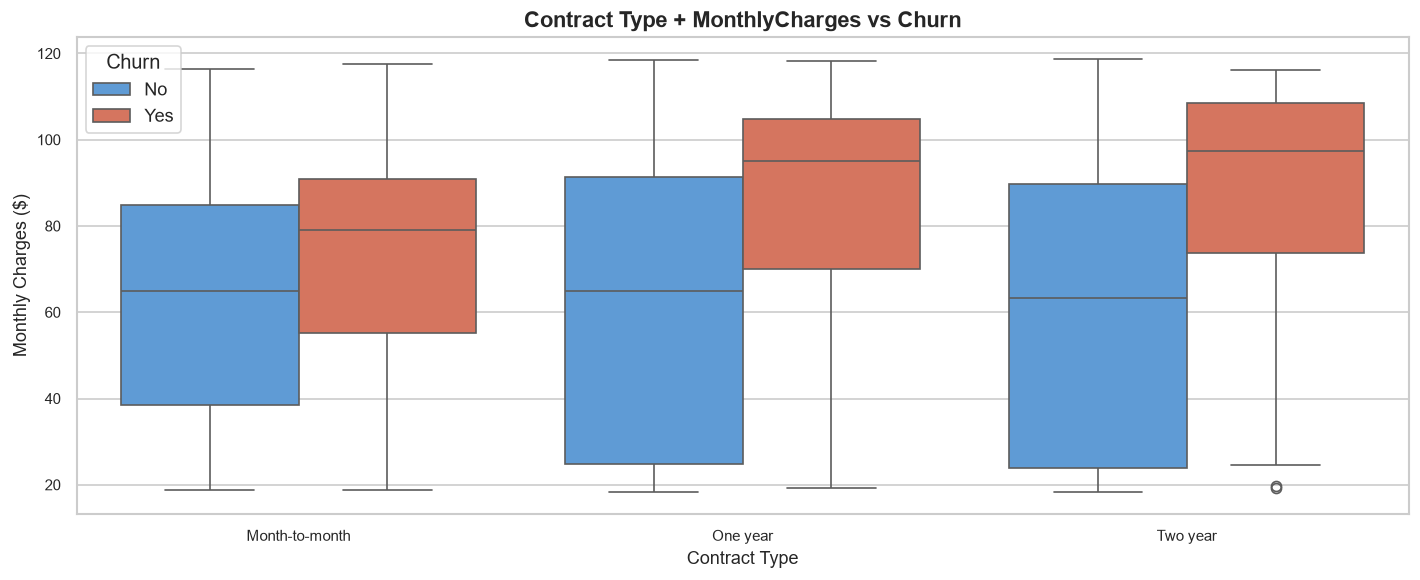

In [20]:
# --- 8.4 MonthlyCharges + Contract + Churn ---
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn',
            palette=CHURN_PALETTE, ax=ax)
ax.set_title('Contract Type + MonthlyCharges vs Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Monthly Charges ($)')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '15_contract_charges_churn.png'), bbox_inches='tight')
plt.show()

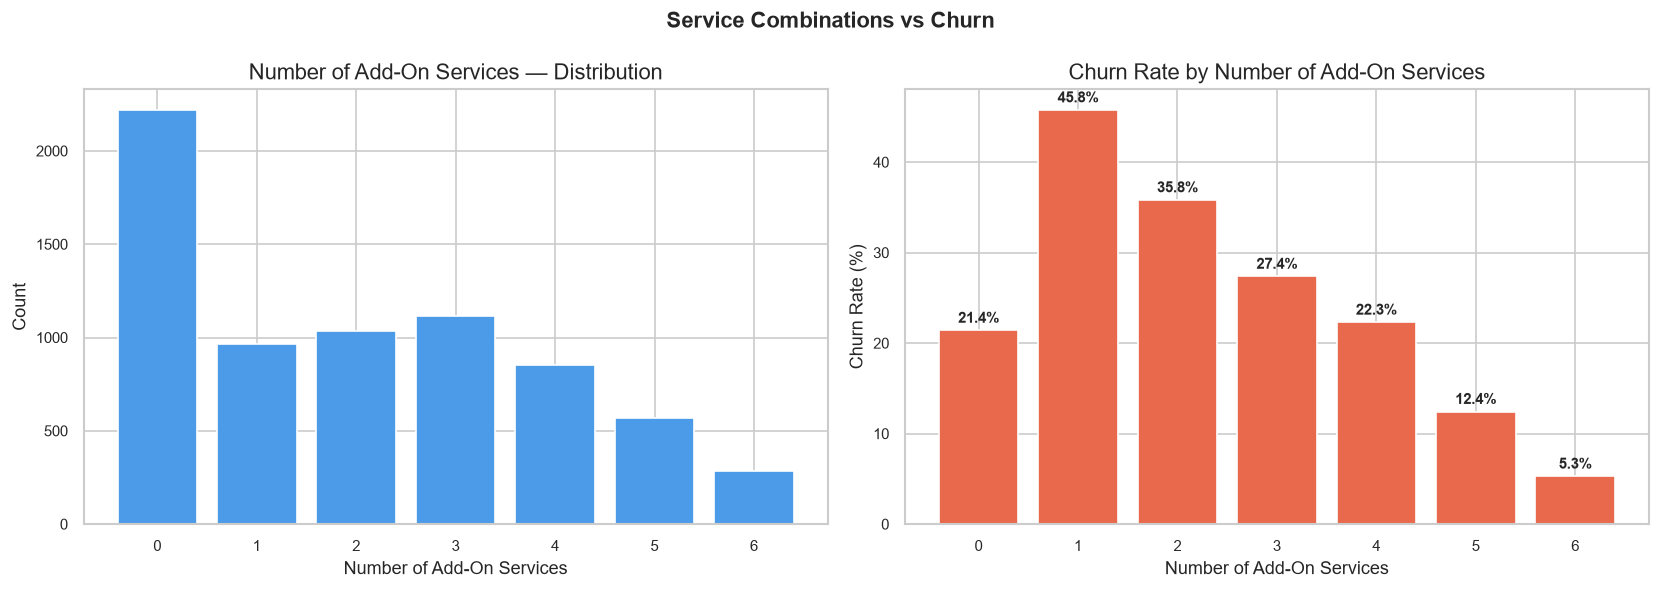

 num_services  Churn Rate (%)
            0       21.406039
            1       45.755694
            2       35.818006
            3       27.370304
            4       22.300469
            5       12.434326
            6        5.281690


In [21]:
# --- 8.5 Service Combination Analysis: Number of add-on services vs Churn ---
service_add_ons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_add_ons].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
counts = df['num_services'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=BAR_COLOR, edgecolor='white')
axes[0].set_title('Number of Add-On Services — Distribution')
axes[0].set_xlabel('Number of Add-On Services')
axes[0].set_ylabel('Count')

# Churn rate by number of services
cr = df.groupby('num_services')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
cr.columns = ['num_services', 'Churn Rate (%)']
bars = axes[1].bar(cr['num_services'], cr['Churn Rate (%)'],
                   color='#E8694C', edgecolor='white')
for bar, v in zip(bars, cr['Churn Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Churn Rate by Number of Add-On Services')
axes[1].set_xlabel('Number of Add-On Services')
axes[1].set_ylabel('Churn Rate (%)')

plt.suptitle('Service Combinations vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '16_service_combo_churn.png'), bbox_inches='tight')
plt.show()

print(cr.to_string(index=False))

## 9. Feature Relationship Summary <a id='9'></a>

| Feature | Observation | Business Impact | Importance |
|---|---|---|---|
| **Contract** | Month-to-month: 43% churn vs Two Year: 3% | Massive; contract type is the single strongest differentiator | 🔴 Very High |
| **Tenure** | Churners median ~10 months vs loyal ~38 months | Critical; new customers are the highest risk segment | 🔴 Very High |
| **InternetService** | Fiber Optic: 42% churn vs DSL: 19% | High; Fiber customers may be paying too much | 🔴 Very High |
| **TechSupport** | No support: 42% vs With support: 15% | High; support access strongly retains customers | 🔵 High |
| **OnlineSecurity** | No security: 42% vs With security: 15% | High; security add-on creates loyalty | 🔵 High |
| **PaymentMethod** | Electronic Check: 45% vs Auto-pay: ~16% | High; payment method reflects commitment level | 🔵 High |
| **MonthlyCharges** | Churners avg $74 vs $61 for loyal | Moderate; higher price drives exit | 🟡 Medium |
| **PaperlessBilling** | Paperless: 34% vs Paper: 17% | Moderate; possibly correlated with other digital behaviours | 🟡 Medium |
| **Partner/Dependents** | No Partner: 33%; No Dependents: 31% churn | Moderate; household type matters | 🟡 Medium |
| **SeniorCitizen** | Senior: 42% churn | Moderate; needs targeted support | 🟡 Medium |
| **OnlineBackup** | No backup: 40% vs With backup: 22% | Moderate; add-on services reduce churn | 🟡 Medium |
| **DeviceProtection** | No protection: 39% vs With protection: 23% | Moderate | 🟡 Medium |
| **StreamingTV/Movies** | Minor difference | Low; streaming adds value but not decisive | 🟢 Low |
| **Gender** | No difference | Negligible; not a churn driver | ⚪ Very Low |
| **PhoneService** | No difference | Negligible | ⚪ Very Low |
| **TotalCharges** | Proxy for tenure; not independently predictive | Low | ⚪ Very Low |

## 10. Top Business Insights <a id='10'></a>

1. 🚨 **Month-to-month customers have the highest churn (~43%)** — the most actionable finding. Easy exit = high exit.
2. 🚨 **New customers (tenure < 12 months) churn the most** — the first year is the critical retention window.
3. 🚨 **Fiber Optic customers churn at ~42%** — nearly twice DSL users. Price or service quality issues suspected.
4. 🚨 **Electronic Check payment users churn at ~45%** — highest of all payment methods.
5. 🚨 **Customers without TechSupport or OnlineSecurity churn at ~42%** — add-ons dramatically reduce churn.
6. ⚠️ **SeniorCitizens churn at ~42%** — significant segment that may need tailored plans.
7. ⚠️ **Higher Monthly Charges are associated with churn** — churners pay ~$13/month more on average.
8. ℹ️ **Having a Partner or Dependents significantly reduces churn** — household accounts are stickier.
9. ℹ️ **Each additional add-on service lowers churn rate** — bundling creates switching costs.
10. ✅ **Gender has no meaningful impact on churn** — not a useful segmentation variable.

## 11. Business Recommendations <a id='11'></a>

| Priority | Recommendation | Target Segment | Expected Impact |
|---|---|---|---|
| 🔴 **1** | **Incentivise contract upgrades** — Offer discounts or perks for switching from month-to-month to annual contracts | Month-to-month customers | Reduce churn from 43% → ~11% |
| 🔴 **2** | **Strengthen customer onboarding** — Assign a success manager and proactive check-ins in months 1–12 | New customers (tenure < 12m) | Reduce early churn significantly |
| 🔴 **3** | **Investigate Fiber Optic pricing and quality** — Survey Fiber customers; assess competitor pricing | Fiber Optic users | Reduce Fiber churn from 42% |
| 🔵 **4** | **Promote auto-payment adoption** — Offer a monthly bill discount for Bank Transfer or Credit Card | Electronic Check users | Reduce payment-related churn |
| 🔵 **5** | **Bundle security + tech support add-ons** — Offer discounted bundles at sign-up | Customers without add-ons | Add-ons reduce churn from 42% → 15% |
| 🔵 **6** | **Create senior-specific plans** — Simplified pricing, dedicated phone support | Senior Citizens | Reduce 42% senior churn |
| 🟡 **7** | **Introduce loyalty pricing** — Progressive discounts as tenure increases | All customers | Reinforce loyalty at 12, 24, 36 month milestones |
| 🟡 **8** | **Launch family/household bundle promotions** — Attract couples and families | Customers without dependents | Household plans increase stickiness |
| 🟢 **9** | **Monitor high-bill customers** — Flag customers paying >$80/month on month-to-month plans | High MonthlyCharges segment | Proactive outreach before they leave |

## 12. Top Churn Drivers <a id='12'></a>

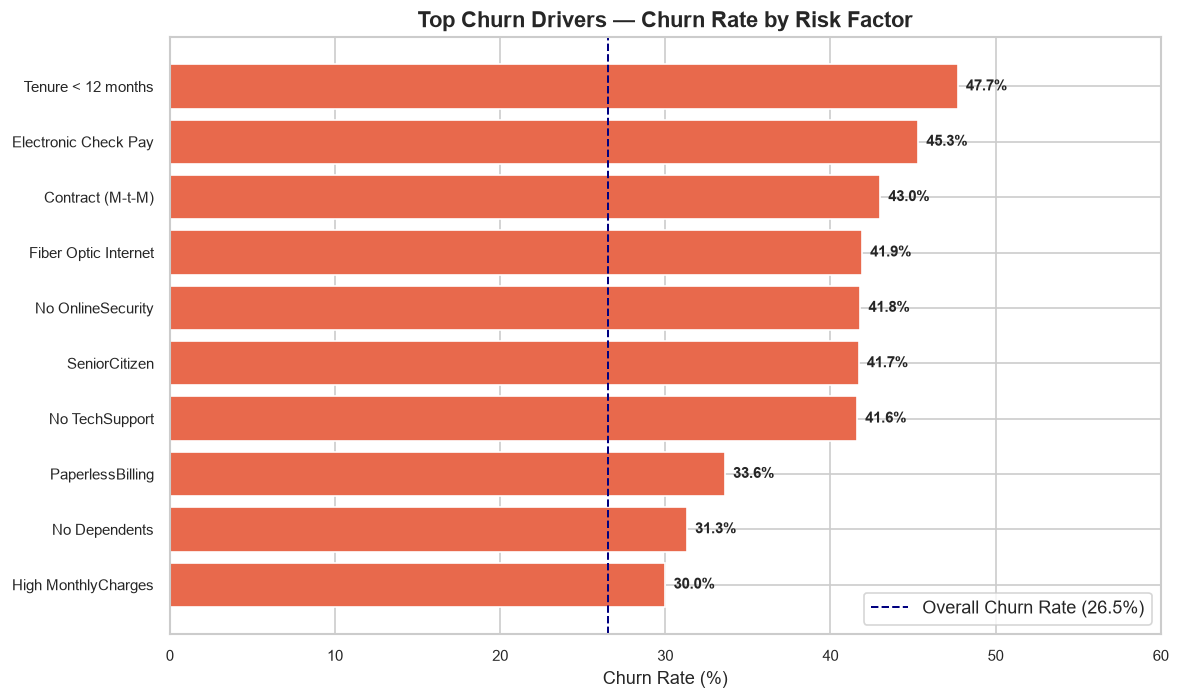

In [22]:
# Visualise top churn drivers by churn rate difference
churn_drivers = {
    'Contract (M-t-M)'       : 43.0,
    'Tenure < 12 months'     : 47.7,
    'Fiber Optic Internet'   : 41.9,
    'No TechSupport'         : 41.6,
    'No OnlineSecurity'      : 41.8,
    'Electronic Check Pay'   : 45.3,
    'SeniorCitizen'          : 41.7,
    'No Dependents'          : 31.3,
    'PaperlessBilling'       : 33.6,
    'High MonthlyCharges'    : 30.0,
}

driver_df = pd.DataFrame(list(churn_drivers.items()),
                         columns=['Driver', 'Churn Rate (%)'])\
              .sort_values('Churn Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(driver_df['Driver'], driver_df['Churn Rate (%)'],
               color='#E8694C', edgecolor='white')
for bar, v in zip(bars, driver_df['Churn Rate (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(x=26.5, color='navy', linestyle='--', linewidth=1.2, label='Overall Churn Rate (26.5%)')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Top Churn Drivers — Churn Rate by Risk Factor', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '17_top_churn_drivers.png'), bbox_inches='tight')
plt.show()

| Rank | Feature | Evidence | Business Impact |
|---|---|---|---|
| 1 | **Contract Type** | Month-to-month: 43% churn; Two Year: 3% | Highest leverage — contract locks reduce churn |
| 2 | **Tenure** | Churners median tenure ~10 months vs ~38 months | Early-stage customer loss is most critical |
| 3 | **InternetService** | Fiber Optic: 42% vs DSL: 19% | Large at-risk segment; pricing or quality issue |
| 4 | **TechSupport** | No support: 42% vs With support: 15% | Strong protective factor |
| 5 | **OnlineSecurity** | No security: 42% vs With security: 15% | Strong protective factor |
| 6 | **PaymentMethod** | Electronic Check: 45% vs Credit Card: 15% | Payment commitment proxy |
| 7 | **SeniorCitizen** | Senior: 42% vs Non-Senior: 24% | Underserved segment |
| 8 | **MonthlyCharges** | Churners avg $74 vs $61 | Price sensitivity |
| 9 | **Partner/Dependents** | No family: 31–33% churn | Household loyalty factor |
| 10 | **OnlineBackup + DeviceProtection** | No add-on: ~39–40% churn | Add-on bundles reduce switching |

## 13. EDA Summary <a id='13'></a>

### What did we learn?
- The dataset has a **26.5% churn rate** — a significant business problem requiring immediate action.
- **Contract type and tenure** are the most decisive churn factors — both reflect customer commitment level.
- **Service add-ons** (TechSupport, OnlineSecurity, OnlineBackup, DeviceProtection) act as strong protective factors.
- **Fiber Optic internet and Electronic Check payments** are concentrated high-churn segments.
- **Household/family customers** (with Partner or Dependents) are significantly more loyal.

### Which features appear most important?
`Contract` | `tenure` | `InternetService` | `TechSupport` | `OnlineSecurity` | `PaymentMethod` | `SeniorCitizen` | `MonthlyCharges`

### Which features appear least important?
`gender` | `PhoneService` | `TotalCharges` (proxy for tenure)

### What should be explored during Feature Engineering?
- **Tenure binning:** Create segments (New: 0–12m, Mid: 13–48m, Loyal: 49–72m)
- **Service score:** Count of add-on services as a single feature
- **Charge-to-tenure ratio:** MonthlyCharges / tenure to capture value perception
- **High-risk flag:** Composite flag for Month-to-Month + Electronic Check + No TechSupport
- **Interaction terms:** Contract × SeniorCitizen, InternetService × MonthlyCharges
- **Encoding strategy:** One-Hot Encoding for nominals; Ordinal for Contract, tenure bins

## 14. Save Important Visualizations <a id='14'></a>

All figures are saved to `reports/figures/` during generation. This cell lists what was saved.

In [23]:
# List all saved figures
print(f"Figures saved to: {FIGURES_DIR}\n")
for f in sorted(os.listdir(FIGURES_DIR)):
    size_kb = os.path.getsize(os.path.join(FIGURES_DIR, f)) / 1024
    print(f"  {f:50s}  {size_kb:6.1f} KB")

Figures saved to: D:\Telco_Customer_Churn\reports\figures

  01_churn_distribution.png                             35.8 KB
  02_demographics_univariate.png                        54.3 KB
  03_tenure_distribution.png                            19.7 KB
  04_account_features_univariate.png                    62.5 KB
  05_service_features_univariate.png                   161.0 KB
  06_financial_features_univariate.png                  65.1 KB
  07_demographics_vs_churn.png                         126.7 KB
  08_tenure_vs_churn.png                                47.7 KB
  09_account_vs_churn.png                              123.4 KB
  10_service_vs_churn.png                              346.8 KB
  11_financial_vs_churn.png                             85.5 KB
  12_correlation_heatmap.png                           258.0 KB
  13_pairplot.png                                      505.0 KB
  14_contract_tenure_churn.png                          34.4 KB
  15_contract_charges_churn.png              

## 15. Conclusion <a id='15'></a>

### EDA Complete ✔️

This EDA has systematically explored all 20 features of the Telco Customer Churn dataset across univariate, bivariate, and multivariate dimensions.

### Key Takeaways
| Theme | Finding |
|---|---|
| **Contract commitment** is the strongest churn lever | Flexible contracts = easy exits |
| **Tenure / loyalty** is highly predictive | New customers are the highest risk |
| **Service add-ons** act as retention shields | Each add-on reduces churn meaningfully |
| **Pricing sensitivity** matters | Churners pay more per month |
| **Household accounts** are more loyal | Family plans reduce switching probability |

### Transition to Feature Engineering
The next notebook (`04_feature_engineering.ipynb`) will:
1. **Bin tenure** into loyalty segments
2. **Create a service score** (count of add-ons)
3. **Encode all categorical variables** appropriately
4. **Engineer interaction features** based on EDA findings
5. **Scale numerical features** for modelling
6. **Handle class imbalance** preparation

---
*Next: 👉 `04_feature_engineering.ipynb`*